# 02 SARIMAX – Klassische Zeitreihenmodelle im Capstone

- **Capstone-Ziel:** ARIMA, SARIMA und SARIMAX in einem konsistenten Workflow trainieren, validieren und zurücktesten.
- **CRISP-DM:** Fokus auf die Modellierungsphase.
- **Input aus Notebook 01:** aufbereitetes Länder-Panel, Metadaten und Fold-Definitionen.
- **Output für Notebook 05:** vergleichbare Prognosen im gemeinsamen Ergebnisschema.
- **Erwarteter Export:** gespeicherte ARIMA-Prognosen für den späteren Gesamtvergleich.

## Inhaltsverzeichnis

- [0 Setup](#0-setup)
- [1 Ausgangslage und Input aus Notebook 01](#1-ausgangslage-und-input-aus-notebook-01)
- [2 Methodik](#2-methodik)
- [3 Datenvorbereitung und Annahmencheck](#3-datenvorbereitung-und-annahmencheck)
- [4 Gemeinsame Forecasting-Bausteine](#4-gemeinsame-forecasting-bausteine)
- [5 Modellauswahl](#5-modellauswahl)
- [6 Walk-Forward-Backtest](#6-walk-forward-backtest)
- [7 Ergebnisse und Diagnostik mit ARIMA](#7-ergebnisse-und-diagnostik-mit-arima)
- [8 Diskussion, Grenzen und Ausblick](#8-diskussion-grenzen-und-ausblick)
- [9 Schnittstelle zu Notebook 05](#9-schnittstelle-zu-notebook-05)

## 0 Setup

Imports, Warnings, Projektkonstanten, Laden des Panels und erste Strukturprüfung.

In [11]:
import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from src import config, data_utils, evaluation

warnings.filterwarnings("ignore")

# 1) Das fertige Panel laden
panel = data_utils.load_panel()          # 1 Zeile pro (country, year)
meta  = data_utils.load_panel_meta()     # Feature-Gruppen, Splits, Ergebnis-Schema

# 2) Struktur prüfen
print(panel.head())
print(panel.columns.tolist())
print(meta["target"])
print(meta["known_future_features"])
print(meta["lagged_features"][:5])

# 3) Ein Fold erzeugen
origin = config.FINAL_ORIGIN
train, test = data_utils.train_test_split(panel, origin_year=origin, horizon=config.HORIZON)

print(f"\nPanel: {panel['country'].nunique()} Länder | Jahre {panel['year'].min()}–{panel['year'].max()}")
print(f"Beispiel-Fold: Train bis {origin}, Test {origin + 1}–{origin + config.HORIZON}")

  country  year  dependency_ratio  gdp_growth  pop_growth  working_age_share  \
0     ABW  1960         83.046159         NaN         NaN          54.632024   
1     ABW  1961         81.969092         NaN    1.187344          54.953804   
2     ABW  1962         81.058317         NaN    1.326227          55.230824   
3     ABW  1963         79.794348         NaN    1.203664          55.618712   
4     ABW  1964         78.152923         NaN    1.076602          56.131658   

   log_gdp_pc_lag1  investment_gdp_lag1  trade_gdp_lag1  inflation_log_lag1  \
0              NaN                  NaN             NaN                 NaN   
1              NaN                  NaN             NaN                 NaN   
2              NaN                  NaN             NaN                 NaN   
3              NaN                  NaN             NaN                 NaN   
4              NaN                  NaN             NaN                 NaN   

   is_global_crisis  
0                 0  


## 1 Ausgangslage und Input aus Notebook 01

Dieses Notebook arbeitet auf dem in Notebook 01 vorbereiteten Länder-Panel und übernimmt dessen Datenlogik unverändert.

- **Datenbasis:** `gdp_panel.csv` und `panel_meta.json` aus der Aufbereitung in Notebook 01
- **Zielvariable:** Prognose von `config.TARGET` im standardisierten Panel-Format
- **Splits/Folds:** identische Walk-Forward-Folds über `data_utils.train_test_split(...)` und `data_utils.iter_backtest_folds(...)`
- **Für dieses Notebook relevant:** ARIMA, SARIMA und SARIMAX nutzen dieselbe Datengrundlage; bei SARIMAX werden nur ex ante bekannte Exogene verwendet

Die ausführliche Begründung zu Datenquellen, Feature-Auswahl, Anti-Leakage-Regeln und Exportkonventionen steht in Notebook 01.

## 2 Methodik

Dieses Notebook vergleicht drei klassische Zeitreihenmodelle in einem einheitlichen Workflow: **ARIMA**, **SARIMA** und **SARIMAX**. 

| Modell | Nutzt vor allem | Stärke | Typische Grenze |
|---|---|---|---|
| **ARIMA** | vergangene Werte der Zielreihe | einfache, starke Baseline für Autokorrelation und Trend | keine explizite saisonale Struktur |
| **SARIMA** | Zielreihe + saisonale Muster | geeignet, wenn sich Mehrjahres-Zyklen wiederholen | bleibt rein univariat |
| **SARIMAX** | Zielreihe + saisonale Muster + exogene Variablen | verbindet Zeitreihenstruktur mit erklärenden Einflussgrößen | exogene Variablen müssen zum Prognosezeitpunkt verfügbar sein |

Für dieses Capstone sind die Modelle aus drei Gründen relevant:

- **Vergleichbare klassische Baselines:** Sie liefern einen transparenten Referenzpunkt für den Vergleich mit TFT und Chronos.
- **Interpretierbarkeit:** Die Vorhersagen der (S)ARIMA(X) Modelle lassen sich besser interpretieren.
- **Bewusste Modellkomplexität:** Klassische Modelle sind einfacher zu analysieren, schneller zu validieren und helfen, unnötige Komplexität zu vermeiden.

Für Jahresdaten interpretieren wir saisonale Terme nicht als Kalender-Saisonalität, sondern als **wiederkehrende Mehrjahres-Zyklen**.

Für eine konkretere, modellnähere Erklärung der Verfahren siehe die `(S)ARIMA(X)`-Live-Demo im Ordner mit den klassischen Methoden.

## 3 Datenvorbereitung und Annahmencheck

Die grundlegende Datenarbeit ist bereits in Notebook 01 abgeschlossen. In diesem Kapitel prüfen wir nur noch, ob das fertige Panel für ARIMA, SARIMA und SARIMAX inhaltlich plausibel ist und welche Modellannahmen für die klassische Zeitreihenmodellierung besonders relevant sind.

### 3.1 Modellrelevanter Input aus Notebook 01

Für dieses Notebook übernehmen wir das vorbereitete Panel unverändert und betrachten nur die für die Modellierung relevanten Punkte:

- **Zielreihe:** `config.TARGET` enthält die jährliche reale BIP-Wachstumsrate in Prozent.
- **Panelstruktur:** eine Zeile pro `(country, year)`.
- **Splits:** identische Walk-Forward-Folds wie in den anderen Modell-Notebooks.
- **Exogene Variablen:** SARIMAX verwendet ausschließlich Merkmale, die über den gesamten Prognosehorizont ex ante verfügbar sind.

### 3.2 Modellannahmen bei Jahresdaten

Für die klassischen Modelle sind hier vor allem drei Punkte wichtig:

- **Kurze Serien je Land:** Die verfügbare Historie ist im Vergleich zu hochfrequenten Zeitreihen begrenzt.
- **Begrenzte kurzfristige Dynamik:** BIP-Wachstum kann eine schwache kurzfristige Eigendynamik aufweisen; ihre Stärke wird daher empirisch geprüft und nicht vorausgesetzt.
- **Saisonale Terme als Zyklus:** Bei Jahresdaten interpretieren wir saisonale Komponenten als wiederkehrende Mehrjahres-Zyklen, nicht als Kalender-Saisonalität.

### 3.3 Plausibilitäts- und Leakage-Checks

Vor der Modellierung gelten für dieses Notebook dieselben Sicherheitsregeln wie im restlichen Capstone:

- **Kein Forecast ohne Fold-Split:** trainiert und bewertet wird nur innerhalb der definierten Walk-Forward-Folds.
- **Keine Zukunftsinformationen:** gelaggte Variablen bleiben gelaggt und werden nicht mit zukünftigen Werten aufgefüllt.
- **SARIMAX nur mit zulässigen Exogenen:** verwendet werden nur Variablen, die ex ante verfügbar sind.

### 3.4 Wahl der saisonalen Zykluslänge

Bei Jahresdaten ist ein saisonaler Term **nicht automatisch sinnvoll**. Anders als bei Monats- oder Quartalsdaten erwarten wir keine echte Kalender-Saisonalität, sondern höchstens grobe **Mehrjahres-Zyklen**. Deshalb behandeln wir SARIMA/SARIMAX hier als optionale Erweiterung und nicht als zwingenden Standard.

Für die Wahl möglicher Zykluslängen nutzen wir vier komplementäre Diagnosen:

- **Dekomposition:** Gibt es neben Trend und Rest überhaupt eine wiederkehrende Komponente?
- **ACF/PACF:** Tauchen bei bestimmten Lags wiederholt Peaks auf?
- **Spektralanalyse / Periodogramm:** Gibt es dominante Frequenzen beziehungsweise plausible Zykluslängen?
- **Länderbeispiele:** Ist ein Muster robust oder nur ein Artefakt des globalen Mittels?

Die Erwartung für dieses Projekt ist vorsichtig: Es kann gut sein, dass **kein stabiler saisonaler Zyklus** vorliegt. Wir testen dennoch die wenigen Kandidaten `5`, `7` und `9` Jahre, um ihren möglichen Prognosemehrwert empirisch zu prüfen.

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

DECOMP_PERIOD = 9
MAX_DIAGNOSTIC_LAG = 15
PREFERRED_COUNTRIES = ["DEU", "USA", "CHN"]


def plot_decomposition(series: pd.Series, title: str, period: int = DECOMP_PERIOD):
    clean = series.dropna().astype(float).sort_index()
    if len(clean) < 2 * period:
        print(
            f"Dekomposition für '{title}' übersprungen: {len(clean)} < {2 * period} Beobachtungen."
        )
        return None, None

    decomposition = seasonal_decompose(
        clean,
        model="additive",
        period=period,
        extrapolate_trend="freq",
    )

    components = pd.DataFrame({
        "observed": decomposition.observed.astype(float),
        "trend": decomposition.trend.astype(float),
        "seasonal": decomposition.seasonal.astype(float),
        "resid": decomposition.resid.astype(float),
    })

    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    for ax, column, ylabel in zip(
        axes,
        ["observed", "trend", "seasonal", "resid"],
        ["Beobachtet", "Trend", "Zyklus", "Residuum"],
    ):
        axes_data = components[column]
        ax.plot(axes_data.index, axes_data.values, color="#1f77b4")
        ax.set_ylabel(ylabel)
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

    axes[0].set_title(title, loc="left")
    axes[-1].set_xlabel("Jahr")
    plt.tight_layout()
    plt.show()

    return decomposition, components


def plot_acf_pacf(series: pd.Series, title: str, max_lag: int = MAX_DIAGNOSTIC_LAG):
    clean = series.dropna().astype(float).sort_index()
    pacf_lag = min(max_lag, max(1, len(clean) // 2 - 1))
    acf_lag = min(max_lag, max(1, len(clean) - 2))

    if len(clean) < 6 or pacf_lag < 1:
        print(f"ACF/PACF für '{title}' übersprungen: zu wenige Beobachtungen.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(clean, lags=acf_lag, ax=axes[0], zero=False)
    axes[0].set_title(f"ACF – {title}")
    axes[0].grid(True, alpha=0.3)

    plot_pacf(clean, lags=pacf_lag, ax=axes[1], zero=False, method="ywm")
    axes[1].set_title(f"PACF – {title}")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_periodogram(series: pd.Series, title: str, candidates: list[int] | None = None):
    clean = series.dropna().astype(float).sort_index()
    if len(clean) < 8:
        print(f"Periodogramm für '{title}' übersprungen: zu wenige Beobachtungen.")
        return pd.DataFrame()

    centered = clean.values - clean.values.mean()
    freqs = np.fft.rfftfreq(len(centered), d=1.0)
    power = np.abs(np.fft.rfft(centered)) ** 2

    positive = freqs > 0
    freqs = freqs[positive]
    power = power[positive]
    periods = 1 / freqs

    valid = periods <= min(len(clean) - 1, 20)
    periods = periods[valid]
    power = power[valid]

    order = np.argsort(periods)
    periods = periods[order]
    power = power[order]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(periods, power, color="#1f77b4", linewidth=2)
    if candidates is not None:
        for candidate in candidates:
            if candidate <= periods.max():
                ax.axvline(candidate, color="#d62728", linestyle="--", linewidth=1, alpha=0.7)
                ax.text(
                    candidate,
                    ax.get_ylim()[1] * 0.92,
                    f"m={candidate}",
                    color="#d62728",
                    ha="center",
                    va="top",
                    fontsize=9,
                )
    ax.set_title(f"Periodogramm – {title}", loc="left")
    ax.set_xlabel("Zykluslänge in Jahren")
    ax.set_ylabel("Spektrale Leistung")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    dominant = (
        pd.DataFrame({"period": periods, "power": power})
        .sort_values("power", ascending=False)
        .head(5)
    )
    return dominant.round({"period": 2, "power": 2})

#### Globale Diagnose

Wir starten mit dem mittleren BIP-Wachstum über alle Länder. Das ist kein Beweis für einen stabilen Zyklus, aber ein sinnvoller erster Überblick, bevor wir einzelne Länder betrachten.

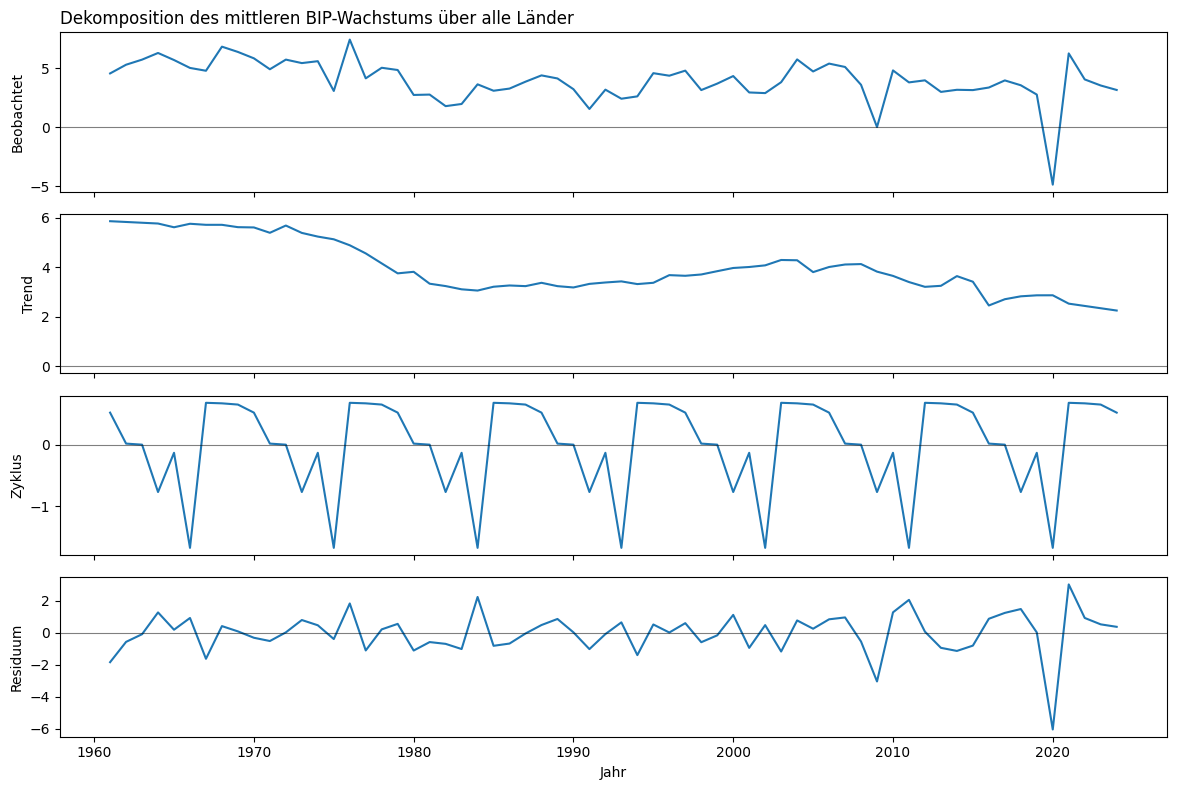

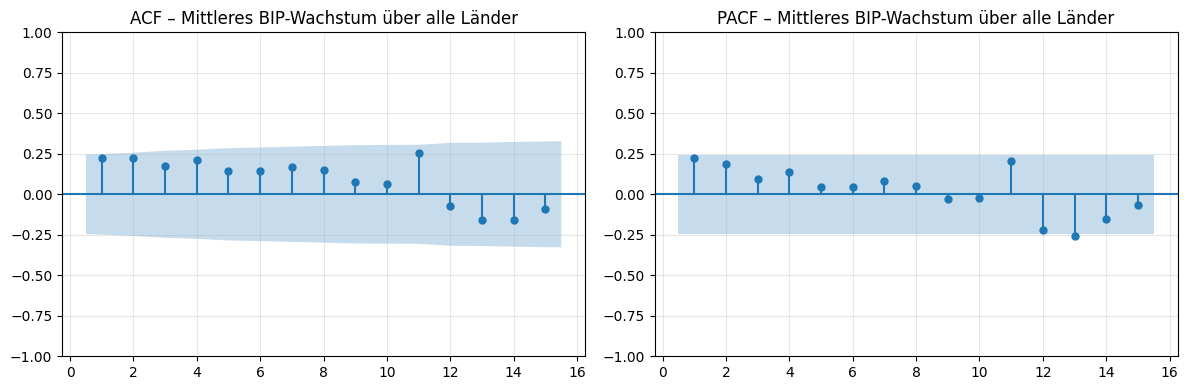

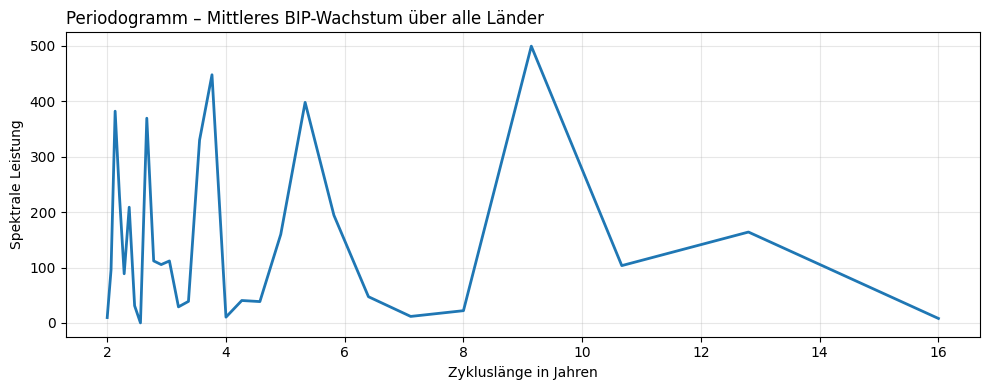

,period,power
25,9.14,499.46
15,3.76,447.86
20,5.33,398.06
2,2.13,382.12
8,2.67,369.46


In [13]:
# Globale Sicht: mittleres BIP-Wachstum über alle Länder je Jahr.
# Für Jahresdaten ist eine saisonale Komponente nur dann plausibel,
# wenn sich wiederkehrende Mehrjahres-Zyklen zeigen.
avg_growth = (
    panel.groupby("year")[config.TARGET]
    .mean()
    .sort_index()
)

avg_decomp, avg_components = plot_decomposition(
    avg_growth,
    title="Dekomposition des mittleren BIP-Wachstums über alle Länder",
)
plot_acf_pacf(avg_growth, "Mittleres BIP-Wachstum über alle Länder")
avg_periodogram = plot_periodogram(avg_growth, "Mittleres BIP-Wachstum über alle Länder")
if not avg_periodogram.empty:
    display(avg_periodogram)


--- Diagnose für DEU ---


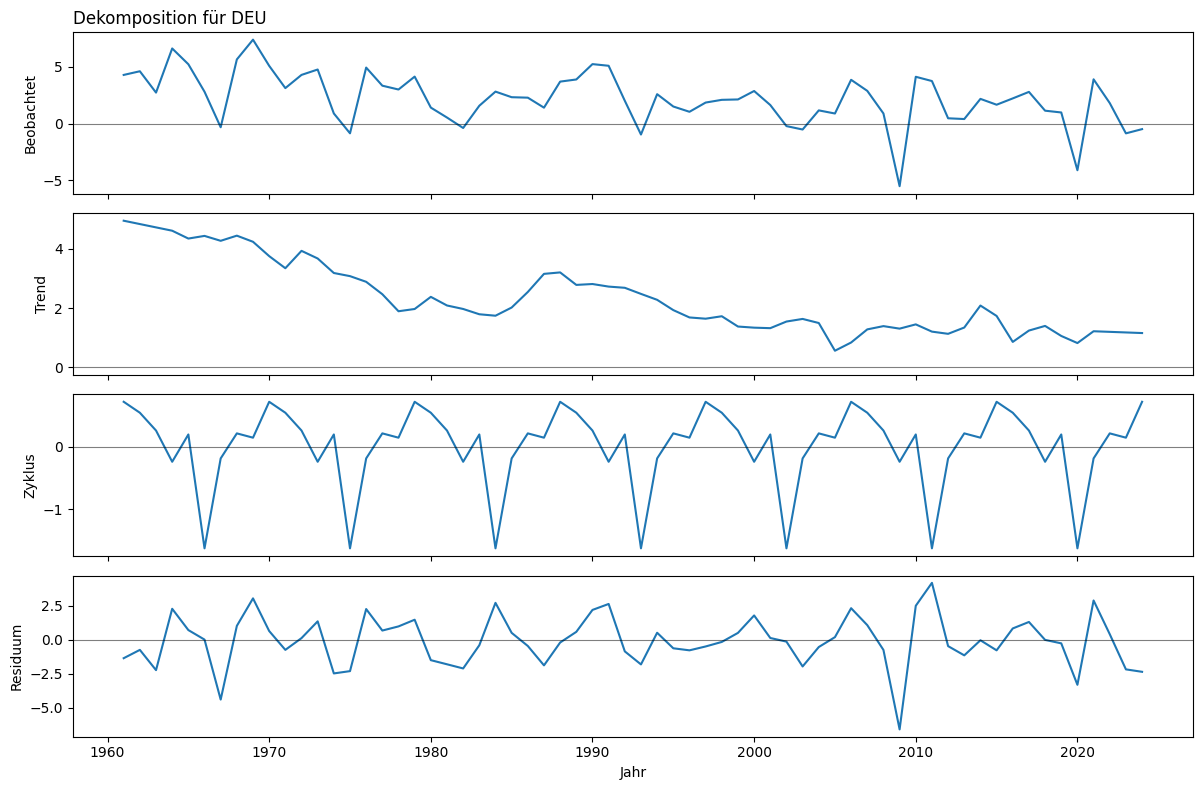

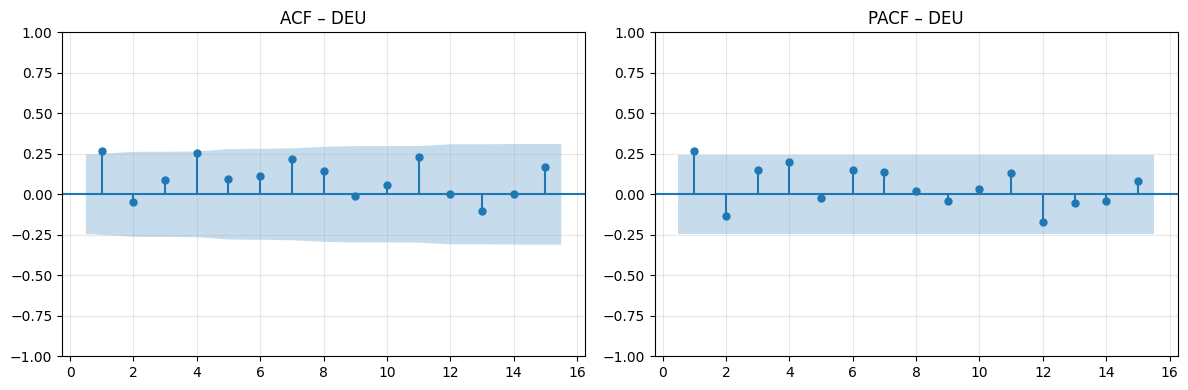

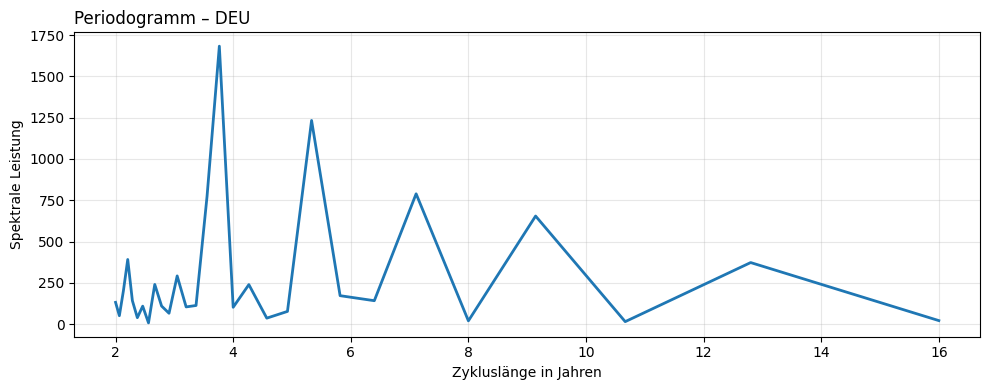

,period,power
15,3.76,1682.65
20,5.33,1232.96
23,7.11,788.84
14,3.56,773.13
25,9.14,654.25



--- Diagnose für USA ---


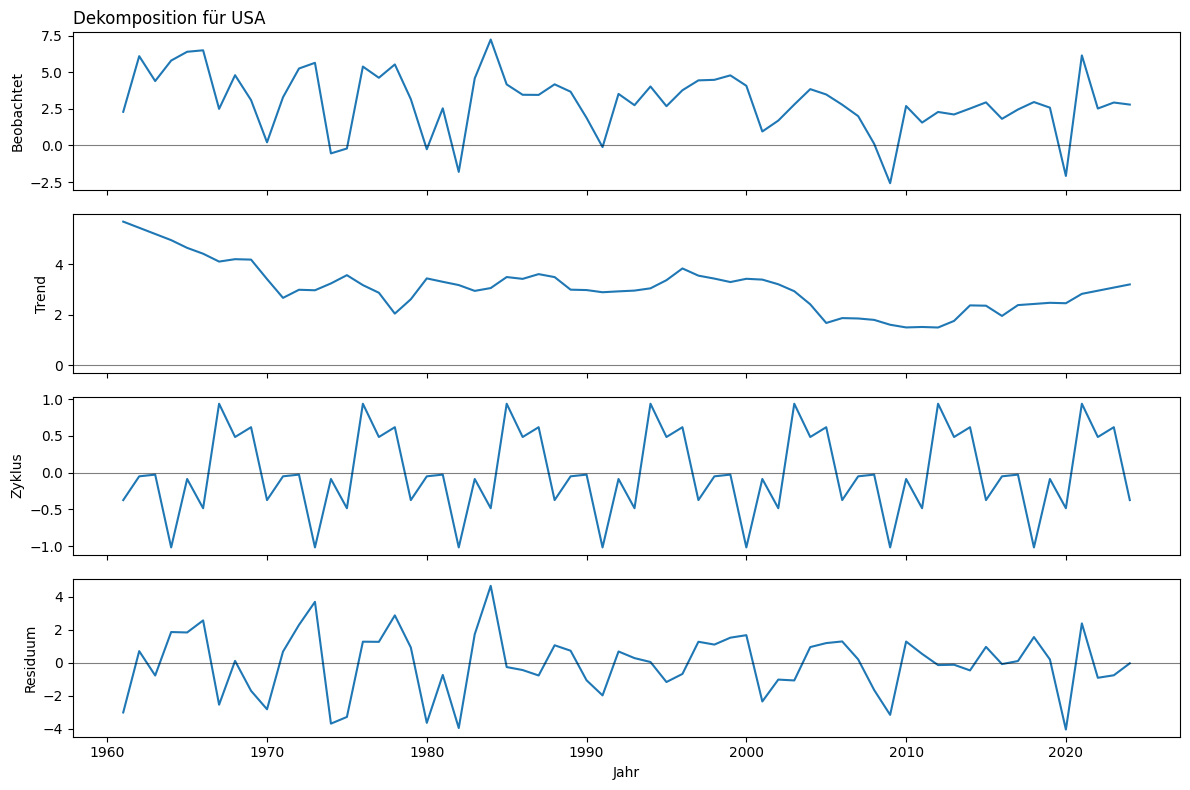

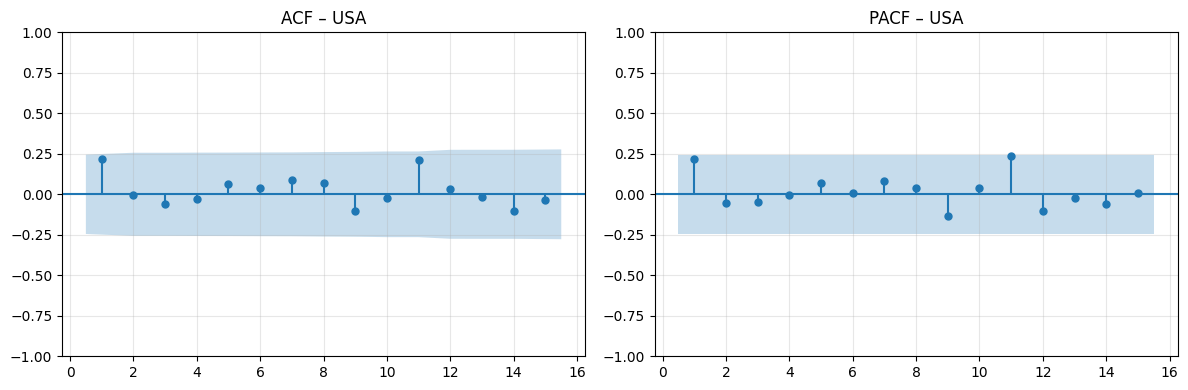

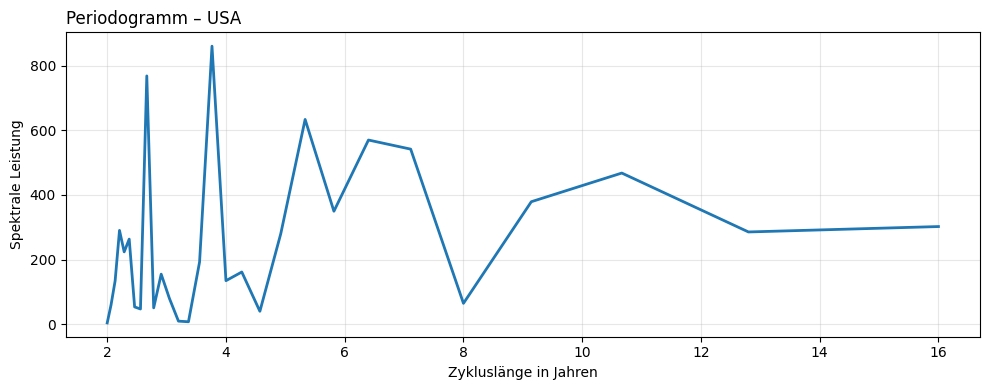

,period,power
15,3.76,859.96
8,2.67,767.94
20,5.33,633.32
22,6.40,569.61
23,7.11,541.46



--- Diagnose für CHN ---


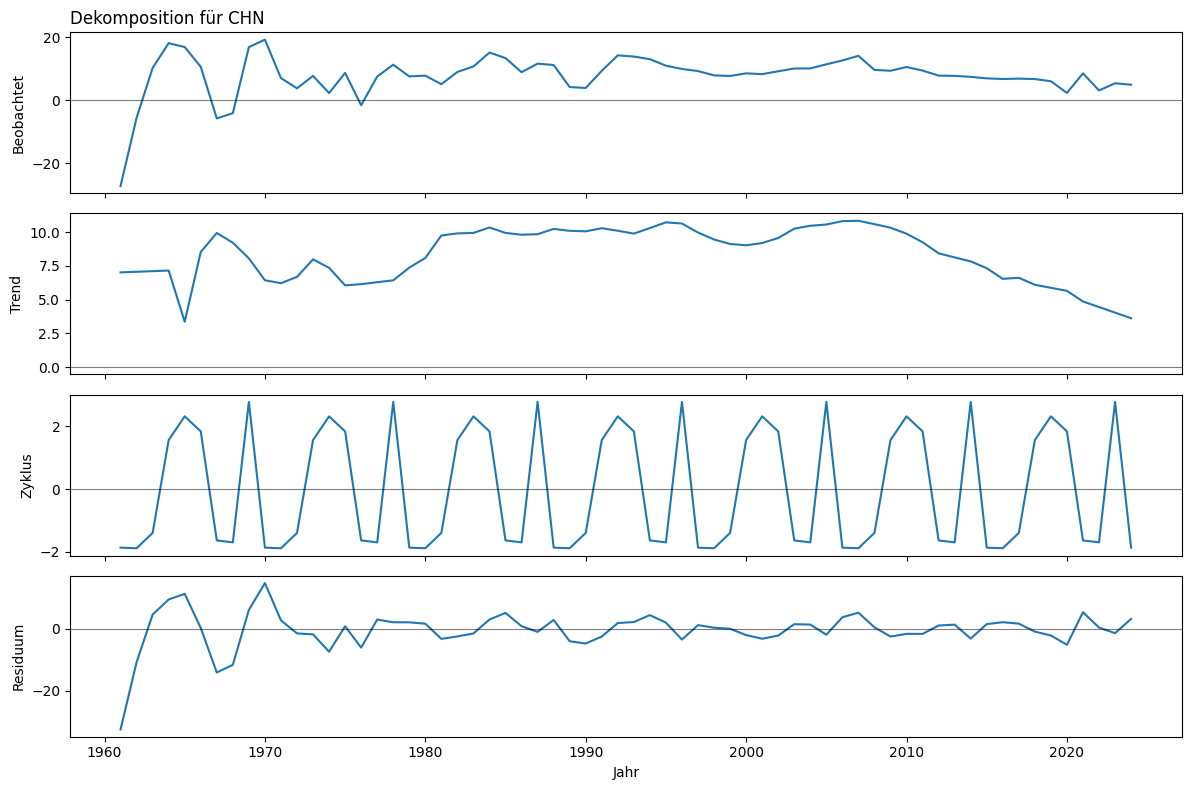

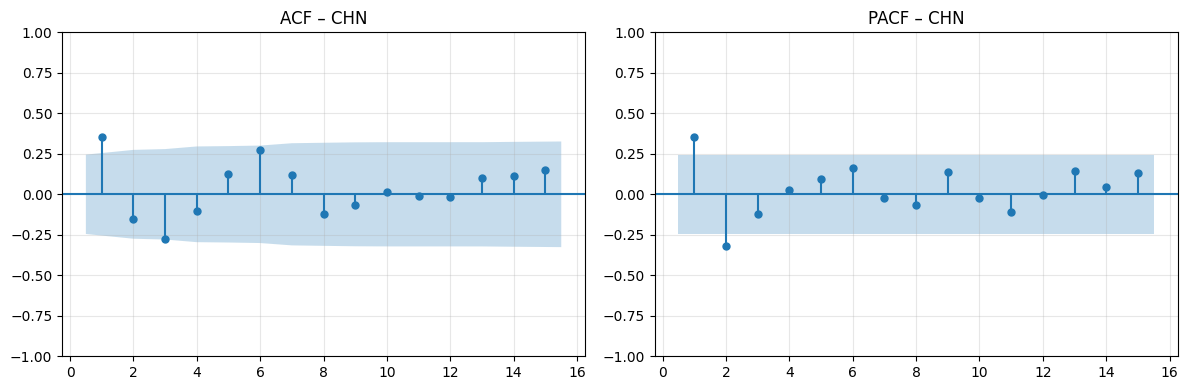

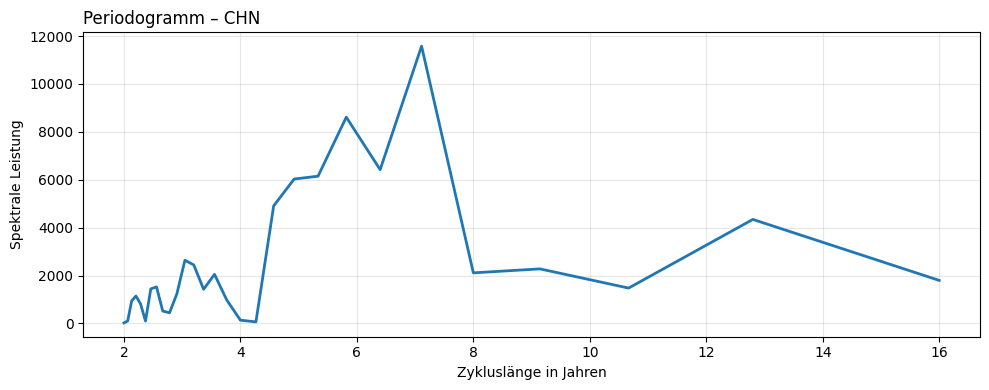

,period,power
23,7.11,11578.79
21,5.82,8614.64
22,6.40,6422.12
20,5.33,6149.63
19,4.92,6030.79


In [14]:
# Zusätzlich mehrere Länderbeispiele prüfen, damit die Wahl von m
# nicht nur auf dem globalen Mittel basiert.
country_examples = [
    country for country in PREFERRED_COUNTRIES if country in panel["country"].unique()
]
if not country_examples:
    country_examples = panel["country"].dropna().sort_values().unique()[:2].tolist()

country_diagnostics = {}
for country in country_examples:
    country_series = (
        panel.loc[panel["country"] == country, ["year", config.TARGET]]
        .dropna()
        .sort_values("year")
        .set_index("year")[config.TARGET]
    )

    print(f"\n--- Diagnose für {country} ---")
    decomp, components = plot_decomposition(
        country_series,
        title=f"Dekomposition für {country}",
    )
    plot_acf_pacf(country_series, f"{country}")
    periodogram = plot_periodogram(country_series, f"{country}")
    if not periodogram.empty:
        display(periodogram)

    country_diagnostics[country] = {
        "series": country_series,
        "decomposition": decomp,
        "components": components,
        "periodogram": periodogram,
    }

if country_examples:
    example_country = country_examples[0]
    country_growth = country_diagnostics[example_country]["series"]
    country_decomp = country_diagnostics[example_country]["decomposition"]
    country_components = country_diagnostics[example_country]["components"]

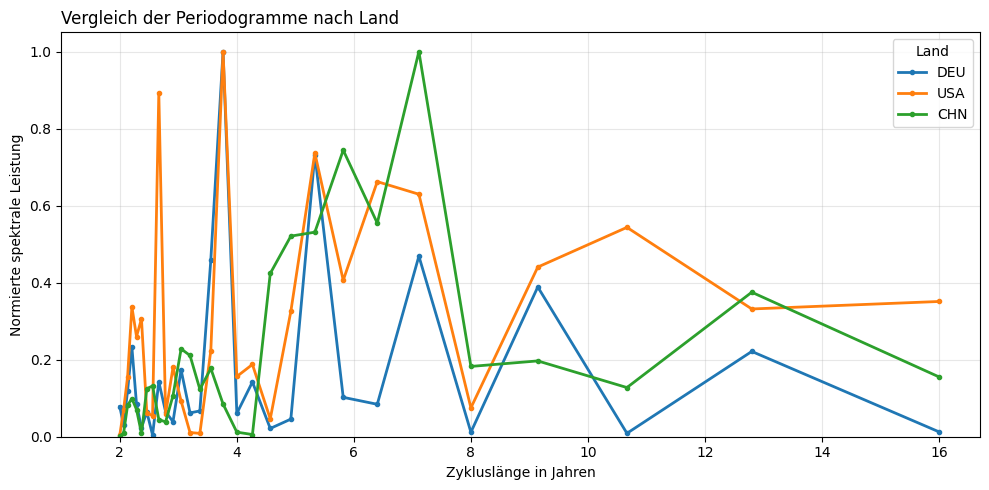

In [15]:
# Gemeinsames Periodogramm: normierte spektrale Leistung je Land vergleichen.
periodogram_countries = [
    country for country in PREFERRED_COUNTRIES if country in panel["country"].unique()
]

fig, ax = plt.subplots(figsize=(10, 5))
for country in periodogram_countries:
    country_series = (
        panel.loc[panel["country"] == country, ["year", config.TARGET]]
        .dropna()
        .sort_values("year")
        .set_index("year")[config.TARGET]
        .astype(float)
    )
    if len(country_series) < 8:
        continue

    centered = country_series.to_numpy() - country_series.mean()
    freqs = np.fft.rfftfreq(len(centered), d=1.0)
    power = np.abs(np.fft.rfft(centered)) ** 2
    positive = freqs > 0
    periods = 1 / freqs[positive]
    power = power[positive]
    valid = periods <= min(len(country_series) - 1, 20)
    periods = periods[valid]
    power = power[valid]
    order = np.argsort(periods)
    periods = periods[order]
    power = power[order]
    if power.max() > 0:
        power = power / power.max()
    ax.plot(periods, power, linewidth=2, marker="o", markersize=3, label=country)

ax.set_title("Vergleich der Periodogramme nach Land", loc="left")
ax.set_xlabel("Zykluslänge in Jahren")
ax.set_ylabel("Normierte spektrale Leistung")
ax.set_xlim(left=1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(title="Land")
plt.tight_layout()
plt.show()

#### Einordnung der Diagnosen

Die Diagnosen sind kein Beweis für einen stabilen saisonalen Zyklus. Bei Jahresdaten und kurzen Länderreihen müssen sie daher vorsichtig interpretiert werden:

- **Große Unterschiede zwischen den Ländern:** Ein Muster im globalen Mittel gilt nicht automatisch für einzelne Länder.
- **Begrenzte Evidenz für Saisonalität:** Dekomposition, ACF/PACF und Periodogramm liefern Hinweise auf mögliche Zyklen, nicht jedoch zwingend auf eine stabile, dominante Struktur.
- **Saisonaler Term nur als Option:** SARIMA und SARIMAX werden empirisch gegen nicht saisonale Spezifikationen geprüft.

Für die folgenden Modellschritte wird eine saisonale Komponente nur beibehalten, wenn sie auf den Validierungsfenstern tatsächlich einen Mehrwert liefert.

#### Arbeitsannahme für die Modellierung

Auch wenn die Evidenz nicht eindeutig ist, halten wir für die weitere Modellierung die Zykluslängen `5`, `7` und `9` für die sinnvollsten Kandidaten. Diese Werte tauchen in mehreren Diagnosen wieder auf und decken kurze bis mittlere Mehrjahres-Zyklen ab, ohne die Suche unnötig breit zu machen.

In [16]:
SEASONAL_CANDIDATES = [5, 7, 9]
print("Verwendete Kandidaten für die weitere Modellierung:", SEASONAL_CANDIDATES)

Verwendete Kandidaten für die weitere Modellierung: [5, 7, 9]


## 4 Gemeinsame Forecasting-Bausteine

Validierungsfenster, Walk-Forward-Logik, Fallback-Regeln bei kurzen Serien, Ergebnis-Schema und gemeinsame Bewertungslogik.

In [17]:
MODEL_MIN_TRAIN_POINTS = 12
DEFAULT_VALIDATION_WINDOWS = [(1990, 1994), (1995, 1999)]


def _prepare_exog(frame: pd.DataFrame, columns: list[str] | None) -> pd.DataFrame | None:
    if not columns:
        return None
    return frame.loc[:, columns].astype(float).fillna(0.0)


def fit_forecast(
    y_train: pd.Series,
    horizon: int,
    order: tuple[int, int, int],
    seasonal_order: tuple[int, int, int, int] = (0, 0, 0, 0),
    exog_train: pd.DataFrame | None = None,
    exog_future: pd.DataFrame | None = None,
    min_train_points: int = MODEL_MIN_TRAIN_POINTS,
) -> np.ndarray:
    y = y_train.dropna().astype(float)
    if len(y) == 0:
        return np.full(horizon, np.nan)

    seasonal_period = seasonal_order[3]
    required_points = max(min_train_points, 2 * seasonal_period) if seasonal_period else min_train_points
    if len(y) < required_points:
        return np.repeat(y.iloc[-1], horizon)

    use_exog = exog_train is not None or exog_future is not None
    if use_exog:
        if exog_train is None or exog_future is None:
            raise ValueError("exog_train und exog_future müssen gemeinsam angegeben werden.")
        exog_train = exog_train.loc[y.index].astype(float)
        exog_future = exog_future.astype(float)

    use_sarimax = use_exog or seasonal_order != (0, 0, 0, 0)
    trend = "c" if order[1] == 0 and seasonal_order[1] == 0 else "n"
    try:
        if use_sarimax:
            fitted = SARIMAX(
                endog=y,
                exog=exog_train,
                order=order,
                seasonal_order=seasonal_order,
                trend=trend,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            forecast_kwargs = {"steps": horizon}
            if use_exog:
                forecast_kwargs["exog"] = exog_future
            return np.asarray(fitted.forecast(**forecast_kwargs), dtype=float)

        fitted = ARIMA(y, order=order, trend=trend).fit()
        return np.asarray(fitted.forecast(steps=horizon), dtype=float)
    except Exception as error:
        warnings.warn(
            f"Forecast-Fallback für order={order}, seasonal_order={seasonal_order}: {error}",
            RuntimeWarning,
        )
        return np.repeat(y.iloc[-1], horizon)


def run_validation_windows(
    panel: pd.DataFrame,
    order: tuple[int, int, int],
    seasonal_order: tuple[int, int, int, int] = (0, 0, 0, 0),
    exog_cols: list[str] | None = None,
    windows: list[tuple[int, int]] | None = None,
) -> pd.DataFrame:
    windows = DEFAULT_VALIDATION_WINDOWS if windows is None else windows
    rows = []
    for start_year, end_year in windows:
        train = panel.loc[panel["year"] < start_year]
        valid = panel.loc[panel["year"].between(start_year, end_year)]
        for country in sorted(valid["country"].unique()):
            country_train = train.loc[train["country"] == country].sort_values("year")
            country_valid = valid.loc[valid["country"] == country].sort_values("year")
            if country_valid.empty:
                continue

            forecast = fit_forecast(
                y_train=country_train[config.TARGET],
                horizon=len(country_valid),
                order=order,
                seasonal_order=seasonal_order,
                exog_train=_prepare_exog(country_train, exog_cols),
                exog_future=_prepare_exog(country_valid, exog_cols),
            )
            for h, (_, row) in enumerate(country_valid.reset_index(drop=True).iterrows(), start=1):
                rows.append({
                    "country": country,
                    "validation_window": f"{start_year}-{end_year}",
                    "origin_year": start_year - 1,
                    "year": int(row["year"]),
                    "h": h,
                    "y_true": float(row[config.TARGET]) if pd.notna(row[config.TARGET]) else np.nan,
                    "y_pred": float(forecast[h - 1]),
                })
    return pd.DataFrame(rows)


def score_model_specs(
    panel: pd.DataFrame,
    order_grid: list[tuple[int, int, int]],
    seasonal_grid: list[tuple[int, int, int, int]] | None = None,
    exog_cols: list[str] | None = None,
    exog_col_grid: list[list[str]] | None = None,
    windows: list[tuple[int, int]] | None = None,
) -> tuple[pd.DataFrame, dict]:
    """Bewertet Modellordnungen und optional mehrere Exogen-Sets.

    Bei mehreren Exogen-Sets wird der Schlüssel der Prognosen um das
    jeweilige Spalten-Tupel erweitert. Bei einem einzelnen Set bleibt der
    bisherige Schlüssel kompatibel.
    """
    if exog_cols is not None and exog_col_grid is not None:
        raise ValueError("Bitte nur exog_cols oder exog_col_grid angeben.")

    seasonal_grid = seasonal_grid or [(0, 0, 0, 0)]
    exog_grid = exog_col_grid if exog_col_grid is not None else [exog_cols]
    exog_grid = exog_grid or [None]
    use_extended_key = len(exog_grid) > 1
    rows, predictions = [], {}

    for order in order_grid:
        for seasonal_order in seasonal_grid:
            for selected_exog in exog_grid:
                preds = run_validation_windows(
                    panel,
                    order,
                    seasonal_order,
                    selected_exog,
                    windows,
                )
                exog_key = tuple(selected_exog or [])
                prediction_key = (
                    (order, seasonal_order, exog_key)
                    if use_extended_key
                    else (order, seasonal_order)
                )
                predictions[prediction_key] = preds
                mases = []
                for (country, window), group in preds.groupby(["country", "validation_window"]):
                    start_year = int(window.split("-")[0])
                    y_train = panel.loc[
                        (panel["country"] == country) & (panel["year"] < start_year),
                        config.TARGET,
                    ]
                    mases.append(evaluation.mase(group["y_true"], group["y_pred"], y_train))
                rows.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "exog_cols": exog_key,
                    "MASE": float(np.nanmean(mases)),
                    "RMSE": evaluation.rmse(preds["y_true"], preds["y_pred"]),
                    "MAE": evaluation.mae(preds["y_true"], preds["y_pred"]),
                    "n_forecasts": int(len(preds)),
                })

    return (
        pd.DataFrame(rows)
        .sort_values(["MASE", "RMSE", "MAE"])
        .reset_index(drop=True),
        predictions,
    )


def run_backtest(
    panel: pd.DataFrame,
    order: tuple[int, int, int],
    seasonal_order: tuple[int, int, int, int] = (0, 0, 0, 0),
    exog_cols: list[str] | None = None,
) -> pd.DataFrame:
    rows = []
    for origin, train, test in data_utils.iter_backtest_folds(panel):
        for country in sorted(test["country"].unique()):
            country_train = train.loc[train["country"] == country].sort_values("year")
            country_test = test.loc[test["country"] == country].sort_values("year")
            if country_test.empty:
                continue
            forecast = fit_forecast(
                y_train=country_train[config.TARGET],
                horizon=len(country_test),
                order=order,
                seasonal_order=seasonal_order,
                exog_train=_prepare_exog(country_train, exog_cols),
                exog_future=_prepare_exog(country_test, exog_cols),
            )
            for h, (_, row) in enumerate(country_test.reset_index(drop=True).iterrows(), start=1):
                rows.append({
                    "country": country,
                    "origin_year": origin,
                    "year": int(row["year"]),
                    "h": h,
                    "y_true": float(row[config.TARGET]) if pd.notna(row[config.TARGET]) else np.nan,
                    "y_pred": float(forecast[h - 1]),
                })
    return pd.DataFrame(rows)


def fit_sarima_forecast(y_train, horizon, order, seasonal_order):
    return fit_forecast(y_train, horizon, order, seasonal_order)


def fit_sarimax_forecast(y_train, exog_train, exog_future, order, seasonal_order):
    return fit_forecast(y_train, len(exog_future), order, seasonal_order, exog_train, exog_future)

## 5 Modellauswahl

ARIMA, SARIMA und SARIMAX werden auf identischen Validierungsfenstern verglichen; je Modelltyp wird die beste Spezifikation bestimmt.

### 5.1 ARIMA

In [18]:
VALIDATION_WINDOWS = DEFAULT_VALIDATION_WINDOWS
ARIMA_ORDER_GRID = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (2, 0, 1),
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
]

validation_scores, validation_preds = score_model_specs(
    panel,
    order_grid=ARIMA_ORDER_GRID,
    windows=VALIDATION_WINDOWS,
)
validation_scores["model"] = "ARIMA"
display(validation_scores.round(3))

best_validation_order = tuple(validation_scores.loc[0, "order"])
best_validation_preds = validation_preds[(best_validation_order, (0, 0, 0, 0))]
print(f"Beste gemeinsame ARIMA-Ordnung: {best_validation_order}")
print("Auswahlkriterium: mittlerer MASE über alle Länder und beide Validierungsfenster.")

def summarize_validation_predictions(predictions: pd.DataFrame) -> pd.DataFrame:
    return (
        predictions.groupby("validation_window")
        .apply(lambda group: pd.Series({
            "MASE": evaluation.mase(group["y_true"], group["y_pred"], panel.loc[panel["country"] == group["country"].iloc[0], config.TARGET]),
            "RMSE": evaluation.rmse(group["y_true"], group["y_pred"]),
            "MAE": evaluation.mae(group["y_true"], group["y_pred"]),
        }))
        .round(3)
    )


display(summarize_validation_predictions(best_validation_preds))

,order,seasonal_order,exog_cols,MASE,RMSE,MAE,n_forecasts,model
0,"(1, 0, 1)","(0, 0, 0, 0)",(),1.014,7.544,4.148,1160,ARIMA
1,"(1, 0, 0)","(0, 0, 0, 0)",(),1.019,7.659,4.149,1160,ARIMA
2,"(0, 0, 1)","(0, 0, 0, 0)",(),1.028,7.671,4.170,1160,ARIMA
3,"(2, 0, 0)","(0, 0, 0, 0)",(),1.030,7.671,4.198,1160,ARIMA
4,"(0, 0, 0)","(0, 0, 0, 0)",(),1.031,7.511,4.157,1160,ARIMA
5,"(1, 1, 1)","(0, 0, 0, 0)",(),1.047,8.039,4.324,1160,ARIMA
6,"(1, 1, 2)","(0, 0, 0, 0)",(),1.061,8.152,4.421,1160,ARIMA
7,"(2, 0, 1)","(0, 0, 0, 0)",(),1.067,7.824,4.375,1160,ARIMA
8,"(0, 1, 1)","(0, 0, 0, 0)",(),1.070,8.043,4.370,1160,ARIMA
9,"(2, 1, 2)","(0, 0, 0, 0)",(),1.070,8.129,4.477,1160,ARIMA


Beste gemeinsame ARIMA-Ordnung: (1, 0, 1)
Auswahlkriterium: mittlerer MASE über alle Länder und beide Validierungsfenster.


,MASE,RMSE,MAE
validation_window,,,
1990-1994,0.846,8.821,4.721
1995-1999,0.642,6.015,3.580


### 5.2 SARIMA

SARIMA wird als optionale Erweiterung mit saisonalen Termen getestet. Ob die zusätzlichen Mehrjahres-Zyklen einen Prognosevorteil bieten, entscheidet ausschließlich die Validierung.

In [19]:
# To save time we used the ones that were promising for ARIMA
SARIMA_ORDER_GRID = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (2, 0, 1),
    (1, 1, 1),
    (1, 1, 2),
]
SARIMA_SEASONAL_ORDER_GRID = [
    seasonal_order
    for m in SEASONAL_CANDIDATES
    for seasonal_order in [(1, 0, 0, m), (0, 0, 1, m)]
]

sarima_validation_scores, sarima_validation_preds = score_model_specs(
    panel,
    order_grid=SARIMA_ORDER_GRID,
    seasonal_grid=SARIMA_SEASONAL_ORDER_GRID,
    windows=VALIDATION_WINDOWS,
)
sarima_validation_scores["model"] = "SARIMA"
display(sarima_validation_scores.head(10).round(3))

best_sarima_row = sarima_validation_scores.loc[0]
SARIMA_ORDER = tuple(best_sarima_row["order"])
SARIMA_SEASONAL_ORDER = tuple(best_sarima_row["seasonal_order"])
best_sarima_validation_preds = sarima_validation_preds[(SARIMA_ORDER, SARIMA_SEASONAL_ORDER)]

print(f"Beste SARIMA-Ordnung: {SARIMA_ORDER}")
print(f"Beste SARIMA-Saisonalität: {SARIMA_SEASONAL_ORDER}")
display(summarize_validation_predictions(best_sarima_validation_preds))

,order,seasonal_order,exog_cols,MASE,RMSE,MAE,n_forecasts,model
0,"(0, 0, 1)","(0, 0, 1, 9)",(),1.029,7.705,4.184,1160,SARIMA
1,"(1, 0, 0)","(0, 0, 1, 9)",(),1.032,7.894,4.259,1160,SARIMA
2,"(0, 0, 1)","(0, 0, 1, 7)",(),1.034,7.706,4.199,1160,SARIMA
3,"(2, 0, 0)","(0, 0, 1, 9)",(),1.039,7.900,4.275,1160,SARIMA
4,"(1, 0, 0)","(0, 0, 1, 7)",(),1.046,8.186,4.310,1160,SARIMA
5,"(0, 0, 0)","(0, 0, 1, 7)",(),1.046,7.560,4.199,1160,SARIMA
6,"(0, 0, 0)","(0, 0, 1, 9)",(),1.047,7.682,4.242,1160,SARIMA
7,"(0, 0, 1)","(1, 0, 0, 9)",(),1.059,8.107,4.367,1160,SARIMA
8,"(1, 0, 0)","(1, 0, 0, 5)",(),1.060,8.352,4.462,1160,SARIMA
9,"(2, 0, 0)","(0, 0, 1, 7)",(),1.062,8.135,4.341,1160,SARIMA


Beste SARIMA-Ordnung: (0, 0, 1)
Beste SARIMA-Saisonalität: (0, 0, 1, 9)


,MASE,RMSE,MAE
validation_window,,,
1990-1994,0.836,8.821,4.664
1995-1999,0.665,6.410,3.708


### 5.3 SARIMAX

#### 5.3.1 Verwendete exogene Variablen

Für SARIMAX unterscheiden wir zwischen **bekannter Zukunft** und **nur bekannter Vergangenheit**:

- **`KNOWN_FUTURE`** darf auch im Prognosehorizont verwendet werden, weil diese Werte für die Zukunft als verfügbar gelten.
- **gelaggte Makrovariablen** enthalten zwar nur alte Informationen, würden bei einer 5-Jahres-Prognose aber nach dem ersten Schritt erneut unbekannte Zwischenjahre voraussetzen.

Anschaulich: Für die Prognose von **2020** ist ein Lag aus **2019** noch bekannt. Für **2021 bis 2024** bräuchte man dann aber Lags aus **2020 bis 2023** und genau diese Werte kennt man beim Start der Prognose noch nicht.

Deshalb verwenden wir im aktuellen Multi-Step-SARIMAX nur Variablen, die über den gesamten Prognosehorizont **ex ante verfügbar** sind.

In [20]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

SARIMAX_EXOG_CANDIDATES = config.KNOWN_FUTURE + ["is_global_crisis"]
first_validation_start = min(start for start in config.ALL_ORIGINS) # until first test window
sarimax_reference_train = panel.loc[panel["year"] < first_validation_start].copy()

print("Exogene Kandidaten für SARIMAX:", SARIMAX_EXOG_CANDIDATES)
print(f"Referenzfenster für die Exogen-Analyse: Jahre < {first_validation_start}")
display(
    sarimax_reference_train[SARIMAX_EXOG_CANDIDATES]
    .describe()
    .T
    .round(3)
)

Exogene Kandidaten für SARIMAX: ['pop_growth', 'working_age_share', 'is_global_crisis']
Referenzfenster für die Exogen-Analyse: Jahre < 1999


,count,mean,std,min,25%,50%,75%,max
pop_growth,4408.0,2.059,1.700,-27.471,1.035,2.187,2.839,21.426
working_age_share,4524.0,57.337,6.422,36.429,51.815,55.545,63.327,74.843
is_global_crisis,4524.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000


#### 5.3.2 Korrelationsmatrix und VIF

Bevor wir das Modell fitten, prüfen wir die exogenen Variablen auf starke Redundanz. Die Korrelationsmatrix gibt einen ersten Überblick, der VIF ergänzt diese Sicht um ein lineares Multikollinearitätsmaß.

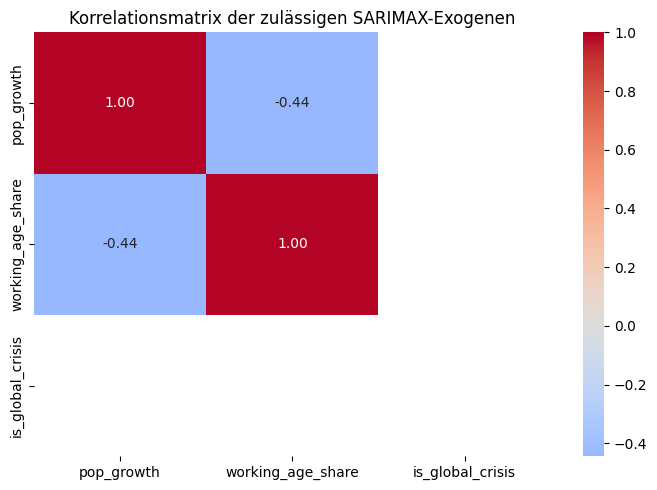

,Variable,VIF
1,working_age_share,1.245
0,pop_growth,1.245
2,is_global_crisis,NaN


In [21]:
corr = sarimax_reference_train[SARIMAX_EXOG_CANDIDATES].dropna().corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Korrelationsmatrix der zulässigen SARIMAX-Exogenen")
plt.tight_layout()
plt.show()

X_vif = sarimax_reference_train[SARIMAX_EXOG_CANDIDATES].dropna()
X_vif_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_vif),
    columns=X_vif.columns,
    index=X_vif.index,
)

sarimax_vif = pd.DataFrame({
    "Variable": X_vif_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled.values, i)
        for i in range(X_vif_scaled.shape[1])
    ],
}).sort_values("VIF", ascending=False)

display(sarimax_vif.round(3))

#### 5.3.3 Auswahl der Exogenen

**Entscheidung für die Exogenen:**
- **behalten:** `working_age_share`, `pop_growth`

Die berücksichtigten Variablen bilden zwei unterschiedliche Einflussbereiche ab:

- **`working_age_share`:** Anteil der Bevölkerung im erwerbsfähigen Alter (15–64 Jahre) in Prozent. Er beschreibt das potenzielle Arbeitskräfteangebot.
- **`pop_growth`:** jährliche Bevölkerungswachstumsrate in Prozent. Sie bildet demografische Dynamik und einen möglichen Einfluss auf Produktion und Nachfrage ab.

Für das reguläre SARIMAX werden nur die ex ante bekannten demografischen Variablen `working_age_share` und `pop_growth` verwendet.

In [22]:
SARIMAX_EXOG_COLS = [
    col for col in SARIMAX_EXOG_CANDIDATES
    if col != "dependency_ratio"
]
print("Finale Exogene für SARIMAX:", SARIMAX_EXOG_COLS)

Finale Exogene für SARIMAX: ['pop_growth', 'working_age_share', 'is_global_crisis']


#### 5.3.4 Spezifikationssuche

Im nächsten Schritt wird SARIMAX direkt auf den Validierungsfenstern getunt. Dabei variieren wir die nicht-saisonale Ordnung und prüfen saisonale Kandidaten, die wir in Kapitel 3 aus den Diagnosen abgeleitet haben. Die Auswahl erfolgt über denselben Bewertungsrahmen wie bei den anderen Modellen, mit **MASE** als Primärkriterium und **RMSE/MAE** als Ergänzung.

#### 5.3.5 SARIMAX mit ex ante bekannten Exogenen

Dieses reguläre SARIMAX-Modell verwendet ausschließlich die zum Prognosezeitpunkt ex ante bekannten demografischen Variablen aus `config.KNOWN_FUTURE`. Vergangene Makroindikatoren und der Krisenindikator sind nicht Teil dieses regulären Modells, weil ihre Werte im gesamten Prognosehorizont nicht verlässlich bekannt sind.

Die nicht-saisonale und saisonale Ordnung wird auf denselben Validierungsfenstern wie bei ARIMA und SARIMA gesucht. Die Auswahl erfolgt primär über **MASE**, ergänzt um **RMSE** und **MAE**. Die folgenden Oracle-Experimente sind davon getrennt und werden weder exportiert noch für die reguläre Modellwahl verwendet.

In [23]:
# Reguläres SARIMAX: ausschließlich ex ante bekannte demografische Treiber.
SARIMAX_EXOG_COLS = list(config.KNOWN_FUTURE)

SARIMAX_ORDER_GRID = SARIMA_ORDER_GRID.copy()
SARIMAX_SEASONAL_ORDER_GRID = [(0, 0, 0, 0)] + [
    seasonal_order
    for m in SEASONAL_CANDIDATES
    for seasonal_order in [(1, 0, 0, m), (0, 0, 1, m)]
]

sarimax_validation_scores, sarimax_validation_preds = score_model_specs(
    panel,
    order_grid=SARIMAX_ORDER_GRID,
    seasonal_grid=SARIMAX_SEASONAL_ORDER_GRID,
    exog_cols=SARIMAX_EXOG_COLS,
    windows=VALIDATION_WINDOWS,
)
sarimax_validation_scores["model"] = "SARIMAX (ex ante)"
display(sarimax_validation_scores.head(15).round(3))

best_sarimax_row = sarimax_validation_scores.loc[0]
SARIMAX_ORDER = tuple(best_sarimax_row["order"])
SARIMAX_SEASONAL_ORDER = tuple(best_sarimax_row["seasonal_order"])
best_sarimax_validation_preds = sarimax_validation_preds[
    (SARIMAX_ORDER, SARIMAX_SEASONAL_ORDER)
]

print(f"Beste SARIMAX-Ordnung: {SARIMAX_ORDER}")
print(f"Beste SARIMAX-Saisonalität: {SARIMAX_SEASONAL_ORDER}")
print("Ex ante verwendete Exogene:", SARIMAX_EXOG_COLS)
display(summarize_validation_predictions(best_sarimax_validation_preds))

# Ein gemeinsamer Vergleich der besten Spezifikationen auf denselben Fenstern.
model_validation_comparison = pd.DataFrame({
    "ARIMA": validation_scores.iloc[0][["MASE", "RMSE", "MAE"]],
    "SARIMA": sarima_validation_scores.iloc[0][["MASE", "RMSE", "MAE"]],
    "SARIMAX (ex ante)": sarimax_validation_scores.iloc[0][["MASE", "RMSE", "MAE"]],
}).T

display(model_validation_comparison.round(3))

,order,seasonal_order,exog_cols,MASE,RMSE,MAE,n_forecasts,model
0,"(1, 0, 0)","(0, 0, 0, 0)","(pop_growth, working_age_share)",1.182,8.681,5.031,1160,SARIMAX (ex ante)
1,"(1, 1, 1)","(0, 0, 0, 0)","(pop_growth, working_age_share)",1.234,8.777,5.235,1160,SARIMAX (ex ante)
2,"(0, 0, 0)","(0, 0, 0, 0)","(pop_growth, working_age_share)",1.246,9.002,5.265,1160,SARIMAX (ex ante)
3,"(1, 0, 0)","(0, 0, 1, 9)","(pop_growth, working_age_share)",1.281,22.514,6.183,1160,SARIMAX (ex ante)
4,"(1, 1, 2)","(0, 0, 0, 0)","(pop_growth, working_age_share)",1.282,12.049,5.610,1160,SARIMAX (ex ante)
5,"(2, 0, 0)","(0, 0, 1, 9)","(pop_growth, working_age_share)",1.288,20.506,6.079,1160,SARIMAX (ex ante)
6,"(0, 0, 1)","(0, 0, 0, 0)","(pop_growth, working_age_share)",1.293,11.365,5.606,1160,SARIMAX (ex ante)
7,"(2, 0, 0)","(0, 0, 0, 0)","(pop_growth, working_age_share)",1.294,12.995,5.761,1160,SARIMAX (ex ante)
8,"(1, 0, 0)","(0, 0, 1, 7)","(pop_growth, working_age_share)",1.296,12.345,5.619,1160,SARIMAX (ex ante)
9,"(1, 0, 1)","(0, 0, 0, 0)","(pop_growth, working_age_share)",1.297,11.877,5.751,1160,SARIMAX (ex ante)


Beste SARIMAX-Ordnung: (1, 0, 0)
Beste SARIMAX-Saisonalität: (0, 0, 0, 0)
Ex ante verwendete Exogene: ['pop_growth', 'working_age_share']


,MASE,RMSE,MAE
validation_window,,,
1990-1994,0.918,8.766,5.123
1995-1999,0.885,8.596,4.939


,MASE,RMSE,MAE
ARIMA,1.013873,7.543534,4.148278
SARIMA,1.029475,7.705135,4.184127
SARIMAX (ex ante),1.182197,8.681069,5.030582


,feature,mean_standardized_coefficient,mean_abs_standardized_coefficient,median_abs_standardized_coefficient,share_p_below_0_05,n_countries
0,working_age_share,-0.084,1.496,0.919,0.155,116
1,pop_growth,0.467,1.494,0.791,0.138,116


SARIMAX-Fits mit Fehler: 0


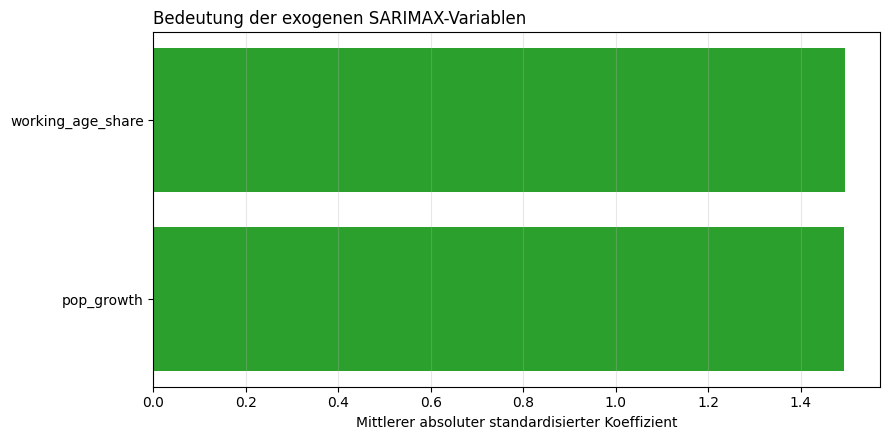

Hinweis: Die Rangfolge beschreibt Modellassoziationen, keine kausalen Effekte. Die Richtung steht in 'mean_standardized_coefficient'.


In [24]:
required_names = [
    "panel",
    "config",
    "SARIMAX",
    "SARIMAX_EXOG_COLS",
    "SARIMAX_ORDER",
    "SARIMAX_SEASONAL_ORDER",
    "SARIMAX_MIN_TRAIN_POINTS",
    "_prepare_exog",
]
SARIMAX_MIN_TRAIN_POINTS = 12

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Bitte zuerst die Setup-, SARIMAX-Spezifikations- und Tuning-Zellen "
        f"ausführen. Fehlende Variablen: {missing_names}"
    )

# die Beträge ihrer Koeffizienten trotz unterschiedlicher Einheiten vergleichbar.
IMPORTANCE_ORIGIN = config.FINAL_ORIGIN
importance_rows = []
failed_importance_fits = 0

for country, country_train in panel.loc[panel["year"] <= IMPORTANCE_ORIGIN].groupby("country"):
    country_train = country_train.sort_values("year")
    y_train = country_train[config.TARGET].dropna().astype(float)
    exog_train = _prepare_exog(country_train, SARIMAX_EXOG_COLS).loc[y_train.index]

    seasonal_period = SARIMAX_SEASONAL_ORDER[3]
    min_points = max(SARIMAX_MIN_TRAIN_POINTS, 2 * seasonal_period) if seasonal_period else SARIMAX_MIN_TRAIN_POINTS
    if len(y_train) < min_points:
        continue

    exog_std = exog_train.std(ddof=0).replace(0.0, np.nan)
    varying_cols = exog_std.dropna().index.tolist()
    if not varying_cols:
        continue

    standardized_exog = (exog_train[varying_cols] - exog_train[varying_cols].mean()) / exog_std[varying_cols]
    trend = "c" if SARIMAX_ORDER[1] == 0 and SARIMAX_SEASONAL_ORDER[1] == 0 else "n"

    try:
        fitted = SARIMAX(
            endog=y_train,
            exog=standardized_exog,
            order=SARIMAX_ORDER,
            seasonal_order=SARIMAX_SEASONAL_ORDER,
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
    except Exception:
        failed_importance_fits += 1
        continue

    for feature in varying_cols:
        importance_rows.append({
            "country": country,
            "feature": feature,
            "coefficient": fitted.params.get(feature, np.nan),
            "p_value": fitted.pvalues.get(feature, np.nan),
        })

exog_coefficients = pd.DataFrame(importance_rows)
assert not exog_coefficients.empty, "Keine stabilen Länder-SARIMAX-Fits für die Exogen-Analyse verfügbar."

exog_importance = (
    exog_coefficients.assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .groupby("feature")
    .agg(
        mean_standardized_coefficient=("coefficient", "mean"),
        mean_abs_standardized_coefficient=("abs_coefficient", "mean"),
        median_abs_standardized_coefficient=("abs_coefficient", "median"),
        share_p_below_0_05=("p_value", lambda values: (values < 0.05).mean()),
        n_countries=("country", "nunique"),
    )
    .sort_values("mean_abs_standardized_coefficient", ascending=False)
    .reset_index()
)

display(exog_importance.round(3))
print(f"SARIMAX-Fits mit Fehler: {failed_importance_fits}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    exog_importance["feature"],
    exog_importance["mean_abs_standardized_coefficient"],
    color="#2ca02c",
)
ax.set_title("Bedeutung der exogenen SARIMAX-Variablen", loc="left")
ax.set_xlabel("Mittlerer absoluter standardisierter Koeffizient")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Hinweis: Die Rangfolge beschreibt Modellassoziationen, keine kausalen Effekte. "
    "Die Richtung steht in 'mean_standardized_coefficient'."
)

#### 5.3.6 Oracle-SARIMAX: hypothetische Obergrenze mit vollständiger Zukunftsinformation

Dieses Experiment ist **bewusst nicht zulässig** und darf weder für die Modellwahl noch für den Export nach Notebook 05 verwendet werden. Das Modell erhält alle verfügbaren Panel-Prädiktoren mit Ausnahme von `dependency_ratio`, einschließlich Variablen, deren Werte im Prognosehorizont in der Realität nicht bekannt wären.

Der Vergleich beantwortet nur die Frage: *Wie gut könnte ein SARIMAX-Modell unter unrealistisch perfekter Kenntnis aller exogenen Treiber werden?* Der Abstand zum regulären SARIMAX zeigt damit den potenziellen Informationswert der heute nicht ex ante verfügbaren Variablen.

In [25]:
# ILLEGAL / ORACLE EXPERIMENT: uses future values of lagged macroeconomic drivers.
# It is an explanatory upper bound only and must never be exported or deployed.
ORACLE_SARIMAX_EXOG_COLS = [
    column
    for column in panel.columns
    if column not in {"country", "year", config.TARGET, "dependency_ratio"}
]

oracle_sarimax_validation_scores, oracle_sarimax_validation_preds = score_model_specs(
    panel,
    order_grid=SARIMAX_ORDER_GRID,
    seasonal_grid=SARIMAX_SEASONAL_ORDER_GRID,
    exog_cols=ORACLE_SARIMAX_EXOG_COLS,
    windows=VALIDATION_WINDOWS,
)
oracle_sarimax_validation_scores["model"] = "SARIMAX oracle (illegal)"
display(oracle_sarimax_validation_scores.head(10).round(3))

best_oracle_sarimax_row = oracle_sarimax_validation_scores.loc[0]
ORACLE_SARIMAX_ORDER = tuple(best_oracle_sarimax_row["order"])
ORACLE_SARIMAX_SEASONAL_ORDER = tuple(best_oracle_sarimax_row["seasonal_order"])
best_oracle_sarimax_validation_preds = oracle_sarimax_validation_preds[
    (ORACLE_SARIMAX_ORDER, ORACLE_SARIMAX_SEASONAL_ORDER)
]

print(f"Oracle-SARIMAX Ordnung: {ORACLE_SARIMAX_ORDER}")
print(f"Oracle-SARIMAX Saisonalität: {ORACLE_SARIMAX_SEASONAL_ORDER}")
print("Illegal verwendete Exogene:", ORACLE_SARIMAX_EXOG_COLS)
display(summarize_validation_predictions(best_oracle_sarimax_validation_preds))

,order,seasonal_order,exog_cols,MASE,RMSE,MAE,n_forecasts,model
0,"(2, 0, 0)","(0, 0, 1, 9)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.488,23.049,6.890,1160,SARIMAX oracle (illegal)
1,"(1, 0, 0)","(0, 0, 1, 9)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.494,20.983,6.859,1160,SARIMAX oracle (illegal)
2,"(0, 0, 1)","(0, 0, 1, 9)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.508,23.817,6.956,1160,SARIMAX oracle (illegal)
3,"(0, 0, 0)","(0, 0, 0, 0)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.545,29.798,7.481,1160,SARIMAX oracle (illegal)
4,"(0, 0, 0)","(0, 0, 1, 9)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.559,24.510,7.174,1160,SARIMAX oracle (illegal)
5,"(1, 0, 1)","(1, 0, 0, 9)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.576,24.127,7.163,1160,SARIMAX oracle (illegal)
6,"(1, 0, 0)","(1, 0, 0, 9)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.595,19.324,7.012,1160,SARIMAX oracle (illegal)
7,"(1, 0, 0)","(0, 0, 0, 0)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.605,26.646,7.747,1160,SARIMAX oracle (illegal)
8,"(1, 0, 1)","(0, 0, 0, 0)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.615,29.073,7.667,1160,SARIMAX oracle (illegal)
9,"(0, 0, 1)","(1, 0, 0, 9)","(pop_growth, working_age_share, log_gdp_pc_lag...",1.616,20.812,7.339,1160,SARIMAX oracle (illegal)


Oracle-SARIMAX Ordnung: (2, 0, 0)
Oracle-SARIMAX Saisonalität: (0, 0, 1, 9)
Illegal verwendete Exogene: ['pop_growth', 'working_age_share', 'log_gdp_pc_lag1', 'investment_gdp_lag1', 'trade_gdp_lag1', 'inflation_log_lag1', 'is_global_crisis']


,MASE,RMSE,MAE
validation_window,,,
1990-1994,1.383,30.915,7.716
1995-1999,1.088,10.508,6.072


#### 5.3.7 Oracle-SARIMAX: hypothetische Obergrenze mit optionaler Zukunftsinformation

Hier werden alle Kombinationen aus höchstens **zwei** Kandidatenvariablen geprüft. Kombinationen, die im Prognosehorizont nicht verfügbare Werte enthalten, sind ausschließlich als hypothetische Obergrenze zu verstehen und dürfen weder für die reguläre Modellwahl noch für den Export verwendet werden.

In [26]:
# ILLEGAL / ORACLE EXPERIMENT: uses future values of lagged macroeconomic drivers.
# It is an explanatory upper bound only and must never be exported or deployed.
from itertools import combinations

ORACLE_SARIMAX_EXOG_CANDIDATES = [
    column
    for column in panel.columns
    if column not in {"country", "year", config.TARGET, "dependency_ratio"}
]
MAX_ORACLE_EXOG_VARS = 2
OPTIONAL_ORICLE_SARIMAX_EXOG_GRID = [
    list(selected_exog)
    for size in range(
        0,
        min(MAX_ORACLE_EXOG_VARS, len(ORACLE_SARIMAX_EXOG_CANDIDATES)) + 1,
    )
    for selected_exog in combinations(ORACLE_SARIMAX_EXOG_CANDIDATES, size)
]

optional_oricle_sarimax_validation_scores, optional_oricle_sarimax_validation_preds = score_model_specs(
    panel,
    order_grid=[SARIMAX_ORDER],
    seasonal_grid=[SARIMAX_SEASONAL_ORDER],
    exog_col_grid=OPTIONAL_ORICLE_SARIMAX_EXOG_GRID,
    windows=VALIDATION_WINDOWS,
)
optional_oricle_sarimax_validation_scores["model"] = "SARIMAX oracle (illegal)"
display(optional_oricle_sarimax_validation_scores.head(15).round(3))

best_optional_oricle_sarimax_row = optional_oricle_sarimax_validation_scores.loc[0]
OPTIONAL_ORICLE_SARIMAX_ORDER = tuple(best_optional_oricle_sarimax_row["order"])
OPTIONAL_ORICLE_SARIMAX_SEASONAL_ORDER = tuple(best_optional_oricle_sarimax_row["seasonal_order"])
OPTIONAL_ORICLE_SARIMAX_EXOG_COLS = list(best_optional_oricle_sarimax_row["exog_cols"])
OPTIONAL_ORICLE_SARIMAX_EXOG_KEY = tuple(OPTIONAL_ORICLE_SARIMAX_EXOG_COLS)
best_optional_oricle_sarimax_validation_preds = optional_oricle_sarimax_validation_preds[
    (
        OPTIONAL_ORICLE_SARIMAX_ORDER,
        OPTIONAL_ORICLE_SARIMAX_SEASONAL_ORDER,
        OPTIONAL_ORICLE_SARIMAX_EXOG_KEY,
    )
]

print(f"Oracle-SARIMAX Ordnung: {OPTIONAL_ORICLE_SARIMAX_ORDER}")
print(f"Oracle-SARIMAX Saisonalität: {OPTIONAL_ORICLE_SARIMAX_SEASONAL_ORDER}")
print(f"Getestete Oracle-Exogen-Sets: {len(OPTIONAL_ORICLE_SARIMAX_EXOG_GRID)}")
print("Beste illegale Exogen-Kombination:", OPTIONAL_ORICLE_SARIMAX_EXOG_COLS or "keine Exogene")
display(summarize_validation_predictions(best_optional_oricle_sarimax_validation_preds))

,order,seasonal_order,exog_cols,MASE,RMSE,MAE,n_forecasts,model
0,"(1, 0, 0)","(0, 0, 0, 0)","(is_global_crisis,)",1.015,7.677,4.147,1160,SARIMAX oracle (illegal)
1,"(1, 0, 0)","(0, 0, 0, 0)",(),1.019,7.659,4.149,1160,SARIMAX oracle (illegal)
2,"(1, 0, 0)","(0, 0, 0, 0)","(inflation_log_lag1, is_global_crisis)",1.054,7.752,4.273,1160,SARIMAX oracle (illegal)
3,"(1, 0, 0)","(0, 0, 0, 0)","(inflation_log_lag1,)",1.054,7.752,4.273,1160,SARIMAX oracle (illegal)
4,"(1, 0, 0)","(0, 0, 0, 0)","(log_gdp_pc_lag1, inflation_log_lag1)",1.082,7.899,4.491,1160,SARIMAX oracle (illegal)
5,"(1, 0, 0)","(0, 0, 0, 0)","(trade_gdp_lag1, is_global_crisis)",1.084,8.776,4.539,1160,SARIMAX oracle (illegal)
6,"(1, 0, 0)","(0, 0, 0, 0)","(trade_gdp_lag1,)",1.084,8.776,4.539,1160,SARIMAX oracle (illegal)
7,"(1, 0, 0)","(0, 0, 0, 0)","(investment_gdp_lag1, inflation_log_lag1)",1.089,8.119,4.505,1160,SARIMAX oracle (illegal)
8,"(1, 0, 0)","(0, 0, 0, 0)","(investment_gdp_lag1,)",1.089,8.183,4.519,1160,SARIMAX oracle (illegal)
9,"(1, 0, 0)","(0, 0, 0, 0)","(investment_gdp_lag1, is_global_crisis)",1.089,8.183,4.519,1160,SARIMAX oracle (illegal)


Oracle-SARIMAX Ordnung: (1, 0, 0)
Oracle-SARIMAX Saisonalität: (0, 0, 0, 0)
Getestete Oracle-Exogen-Sets: 29
Beste illegale Exogen-Kombination: ['is_global_crisis']


,MASE,RMSE,MAE
validation_window,,,
1990-1994,0.847,8.911,4.725
1995-1999,0.641,6.215,3.574


## 6 Walk-Forward Backtest

Die auf den Validierungsfenstern ausgewählten Spezifikationen werden auf **allen** definierten Folds zurückgetestet. ARIMA, SARIMA und das reguläre SARIMAX verwenden dabei identische Forecast-Origins, Horizonte und Bewertungsmetriken.

Die Validierungsfenster in Abschnitt 5 dienen der Spezifikationsauswahl. Der Backtest in diesem Abschnitt beschreibt anschließend die Leistung über die vollständige Fold-Struktur.

In [27]:
# Final model selection must be checked on all walk-forward folds, not only the
# two tuning windows. Every model uses the same origins, horizon, and metrics.
preds_arima_df = run_backtest(
    panel,
    order=best_validation_order,
)
preds_sarima_df = run_backtest(
    panel,
    order=SARIMA_ORDER,
    seasonal_order=SARIMA_SEASONAL_ORDER,
)
preds_sarimax_df = run_backtest(
    panel,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL_ORDER,
    exog_cols=SARIMAX_EXOG_COLS,
)
preds_oracle_sarimax_df = run_backtest(
    panel,
    order=ORACLE_SARIMAX_ORDER,
    seasonal_order=ORACLE_SARIMAX_SEASONAL_ORDER,
    exog_cols=ORACLE_SARIMAX_EXOG_COLS,
)

preds_optional_oracle_sarimax_df = run_backtest(
    panel,
    order=ORACLE_SARIMAX_ORDER,
    seasonal_order=ORACLE_SARIMAX_SEASONAL_ORDER,
    exog_cols="is_global_crisis",
)

backtest_predictions = {
    "arima": preds_arima_df,
    "sarima": preds_sarima_df,
    "sarimax": preds_sarimax_df,
    "oracle_sarimax": preds_oracle_sarimax_df,
    "optional_oracle_sarimax": preds_optional_oracle_sarimax_df,
}
backtest_evaluations = {
    model: predictions.assign(model=model, q10=np.nan, q90=np.nan)
    for model, predictions in backtest_predictions.items()
}
backtest_comparison = pd.concat(
    [evaluation.summarize(predictions, panel) for predictions in backtest_evaluations.values()],
    ignore_index=True,
)

display(backtest_comparison.round(3))
print("Forecasts je Modell:", {model: len(predictions) for model, predictions in backtest_predictions.items()})

,model,MASE,RMSE,MAE,pinball_q10,pinball_q90,coverage_80,n_forecasts
0,arima,0.840,5.336,3.105,NaN,NaN,NaN,2900
1,sarima,0.884,5.512,3.258,NaN,NaN,NaN,2900
2,sarimax,0.963,6.120,3.654,NaN,NaN,NaN,2900
3,oracle_sarimax,1.796,61.490,7.326,NaN,NaN,NaN,2900
4,optional_oracle_sarimax,0.846,5.485,3.171,NaN,NaN,NaN,2900


Forecasts je Modell: {'arima': 2900, 'sarima': 2900, 'sarimax': 2900, 'oracle_sarimax': 2900, 'optional_oracle_sarimax': 2900}


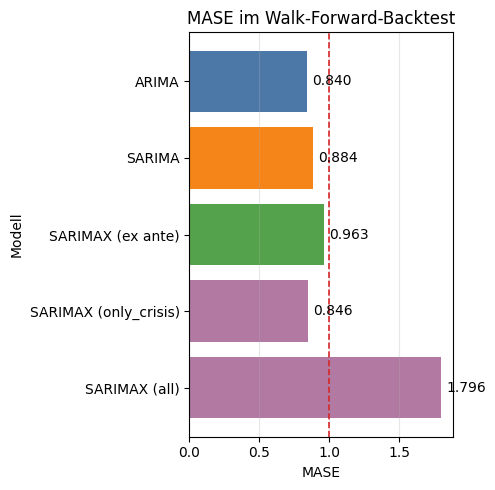

In [28]:
# Modelle auswählen und gleichzeitig die Reihenfolge des Plots festlegen.
MASE_PLOT_MODELS = ["arima", "sarima", "sarimax", "optional_oracle_sarimax", "oracle_sarimax"]
MASE_PLOT_COLORS = {
    "arima": "#4C78A8",
    "sarima": "#F58518",
    "sarimax": "#54A24B",
    "oracle_sarimax": "#B279A2",
    "optional_oracle_sarimax": "#B279A2",
}
MASE_PLOT_LABELS = {
    "arima": "ARIMA",
    "sarima": "SARIMA",
    "sarimax": "SARIMAX (ex ante)",
    "oracle_sarimax": "SARIMAX (all)",
    "optional_oracle_sarimax": "SARIMAX (only_crisis)",
}

available_models = set(backtest_comparison["model"].dropna())
unknown_models = set(MASE_PLOT_MODELS) - available_models
if unknown_models:
    raise ValueError(f"Unbekannte Modelle in MASE_PLOT_MODELS: {sorted(unknown_models)}")
missing_colors = set(MASE_PLOT_MODELS) - set(MASE_PLOT_COLORS)
if missing_colors:
    raise ValueError(f"Fehlende Farben in MASE_PLOT_COLORS: {sorted(missing_colors)}")
missing_labels = set(MASE_PLOT_MODELS) - set(MASE_PLOT_LABELS)
if missing_labels:
    raise ValueError(f"Fehlende Namen in MASE_PLOT_LABELS: {sorted(missing_labels)}")

mase_plot_data = (
    backtest_comparison[["model", "MASE"]]
    .dropna(subset=["MASE"])
    .set_index("model")
    .reindex(MASE_PLOT_MODELS)
    .dropna(subset=["MASE"])
    .reset_index()
)
mase_plot_data["plot_label"] = mase_plot_data["model"].map(MASE_PLOT_LABELS)

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.barh(
    mase_plot_data["plot_label"],
    mase_plot_data["MASE"],
    color=[MASE_PLOT_COLORS[model] for model in mase_plot_data["model"]],
)
ax.axvline(1.0, color="#d62728", linestyle="--", linewidth=1.2, label="Naive Referenz (MASE = 1)")
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_title("MASE im Walk-Forward-Backtest")
ax.set_xlabel("MASE")
ax.set_ylabel("Modell")
ax.invert_yaxis()
ax.set_xlim(left=0)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 7 Ergebnisse und Diagnostik mit ARIMA

Dieser Abschnitt betrachtet ARIMA als das in Abschnitt 6 ausgewählte Referenzmodell. Er umfasst die Auswertung mit `evaluation.summarize(...)`, die Residualdiagnostik, den Vergleich mit der naiven MASE-Referenz sowie die Fehleranalyse nach Region und Einkommensgruppe.

,model,MASE,RMSE,MAE,pinball_q10,pinball_q90,coverage_80,n_forecasts
0,arima,0.84,5.336,3.105,NaN,NaN,NaN,2900


(<Figure size 1380x1100 with 6 Axes>,
 array([<Axes: title={'left': 'Residuals nach Jahr'}, xlabel='Testjahr', ylabel='Fehler'>,
        <Axes: title={'left': 'Residuals gegen Punktprognose (Anzeige P10-P90)'}, xlabel='Punktprognose', ylabel='Fehler'>,
        <Axes: title={'left': 'Residualverteilung (Anzeige P1-P99)'}, xlabel='Fehler', ylabel='Dichte'>,
        <Axes: title={'left': 'Q-Q-Plot'}, xlabel='Theoretische Quantile', ylabel='Residual-Quantile'>,
        <Axes: title={'left': 'Fehlerkorrelation nach Horizontabstand'}, xlabel='Lag innerhalb des Forecast-Horizonts', ylabel='Korrelation'>,
        <Axes: title={'left': 'Residuals nach Horizont (Anzeige P1-P99)'}, xlabel='Forecast-Horizont h', ylabel='Fehler'>],
       dtype=object))

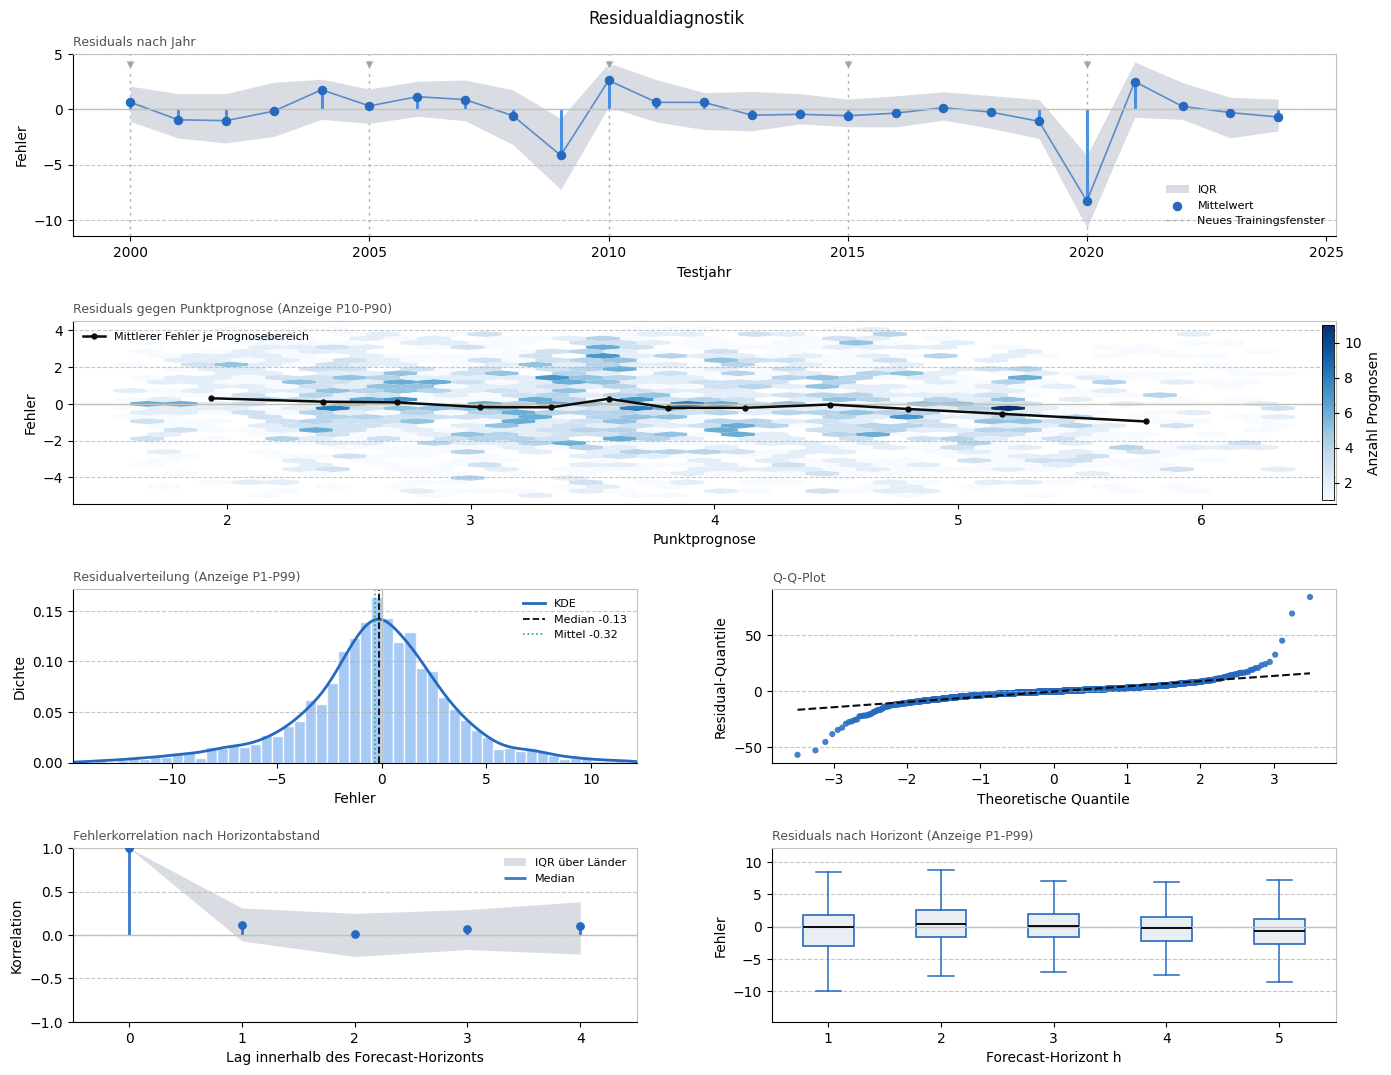

In [29]:
preds_eval = preds_arima_df.assign(model="arima", q10=np.nan, q90=np.nan)

summary = evaluation.summarize(preds_eval, panel)
display(summary.round(3))

evaluation.plot_residual_diagnostics(preds_eval)

,region,RMSE,MAE,n_forecasts,n_countries,MASE,MASE_std,n_folds
0,Sub-Saharan Africa,4.774,3.080,675,27,0.652,0.492,135
1,"Middle East, North Africa, Afghanistan & Pakistan",8.288,4.227,375,15,0.664,0.580,75
2,South Asia,3.400,2.406,125,5,0.800,0.552,25
3,North America,2.287,1.596,50,2,0.844,0.397,10
4,East Asia & Pacific,6.028,3.171,500,20,0.881,0.695,100
5,Latin America & Caribbean,4.332,2.879,500,20,0.921,0.640,100
6,Europe & Central Asia,4.243,2.868,675,27,1.042,0.618,135


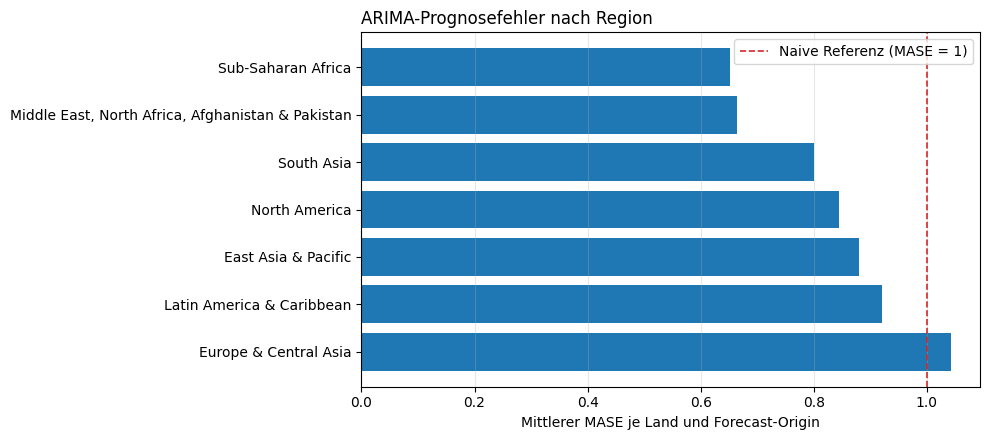

,income_group,RMSE,MAE,n_forecasts,n_countries,MASE,MASE_std,n_folds
0,Low income,5.496,3.353,275,11,0.632,0.469,55
1,Lower middle income,3.550,2.563,675,27,0.637,0.423,135
2,Upper middle income,6.667,3.564,800,32,0.922,0.706,160
3,High income,5.123,3.046,1150,46,0.951,0.635,230


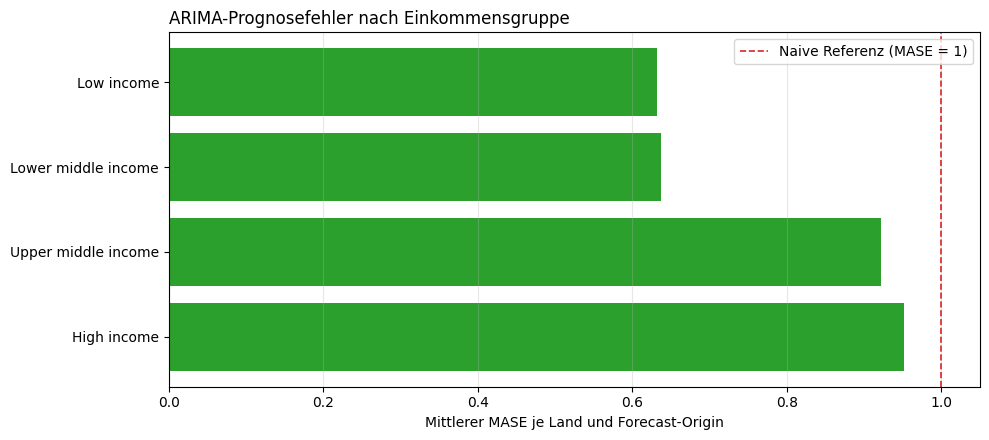

In [30]:
# Regionale Fehleranalyse: MASE wird zunächst pro (Land, Origin) berechnet,
# damit Regionen mit mehr Ländern oder Folds die Auswertung nicht dominieren.
static_meta = data_utils.download_country_meta()
country_lookup = static_meta[["country", "region", "income_group"]].drop_duplicates("country")

regional_preds = preds_eval.merge(country_lookup[["country", "region"]], on="country", how="left")
regional_preds = regional_preds.dropna(subset=["region", "y_true", "y_pred"])

regional_fold_mase = []
for (country, origin_year), group in regional_preds.groupby(["country", "origin_year"]):
    y_train = panel.loc[
        (panel["country"] == country) & (panel["year"] <= origin_year),
        config.TARGET,
    ]
    regional_fold_mase.append({
        "country": country,
        "origin_year": origin_year,
        "MASE": evaluation.mase(group["y_true"], group["y_pred"], y_train),
    })

regional_mase = (
    pd.DataFrame(regional_fold_mase)
    .merge(country_lookup[["country", "region"]], on="country", how="left")
)
regional_error_summary = (
    regional_preds.groupby("region")
    .agg(
        RMSE=("y_true", lambda y: evaluation.rmse(y, regional_preds.loc[y.index, "y_pred"])),
        MAE=("y_true", lambda y: evaluation.mae(y, regional_preds.loc[y.index, "y_pred"])),
        n_forecasts=("year", "size"),
        n_countries=("country", "nunique"),
    )
    .join(regional_mase.groupby("region")["MASE"].agg(["mean", "std", "count"]))
    .rename(columns={"mean": "MASE", "std": "MASE_std", "count": "n_folds"})
    .sort_values("MASE")
    .reset_index()
)

display(regional_error_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(
    regional_error_summary["region"],
    regional_error_summary["MASE"],
    color="#1f77b4",
)
ax.axvline(1.0, color="#d62728", linestyle="--", linewidth=1.2, label="Naive Referenz (MASE = 1)")
ax.set_title("ARIMA-Prognosefehler nach Region", loc="left")
ax.set_xlabel("Mittlerer MASE je Land und Forecast-Origin")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Einkommensgruppenanalyse: dieselbe Aggregationslogik nach World-Bank-Income-Level.
income_preds = preds_eval.merge(
    country_lookup[["country", "income_group"]],
    on="country",
    how="left",
)
income_preds = income_preds.dropna(subset=["income_group", "y_true", "y_pred"])

income_fold_mase = []
for (country, origin_year), group in income_preds.groupby(["country", "origin_year"]):
    y_train = panel.loc[
        (panel["country"] == country) & (panel["year"] <= origin_year),
        config.TARGET,
    ]
    income_fold_mase.append({
        "country": country,
        "origin_year": origin_year,
        "MASE": evaluation.mase(group["y_true"], group["y_pred"], y_train),
    })

income_mase = (
    pd.DataFrame(income_fold_mase)
    .merge(country_lookup[["country", "income_group"]], on="country", how="left")
)
income_error_summary = (
    income_preds.groupby("income_group")
    .agg(
        RMSE=("y_true", lambda y: evaluation.rmse(y, income_preds.loc[y.index, "y_pred"])),
        MAE=("y_true", lambda y: evaluation.mae(y, income_preds.loc[y.index, "y_pred"])),
        n_forecasts=("year", "size"),
        n_countries=("country", "nunique"),
    )
    .join(income_mase.groupby("income_group")["MASE"].agg(["mean", "std", "count"]))
    .rename(columns={"mean": "MASE", "std": "MASE_std", "count": "n_folds"})
    .sort_values("MASE")
    .reset_index()
)

display(income_error_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(
    income_error_summary["income_group"],
    income_error_summary["MASE"],
    color="#2ca02c",
)
ax.axvline(1.0, color="#d62728", linestyle="--", linewidth=1.2, label="Naive Referenz (MASE = 1)")
ax.set_title("ARIMA-Prognosefehler nach Einkommensgruppe", loc="left")
ax.set_xlabel("Mittlerer MASE je Land und Forecast-Origin")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 8 Diskussion, Grenzen und Ausblick

Einordnung der klassischen Modelle bei Jahresdaten, Nutzen exogener Variablen und Brücke zum notebookübergreifenden Modellvergleich.

### 8.1 Einfache Modelle als starke Referenz

Die Ausgaben der Validierung und des Walk-Forward-Backtests in den Abschnitten 5 und 6 zeigen, welches der getesteten Modelle die niedrigste Fehlerkennzahl erreicht. Da ARIMA dort die beste Leistung erzielt, spricht das dafür, dass die zusätzlich modellierte Mehrjahres-Saisonalität und die verwendeten ex ante bekannten exogenen Variablen unter den gegebenen Daten keinen stabilen Prognosevorteil liefern.

Ein ARIMA-Modell ohne Differenzierung und ohne saisonale Komponente beschreibt die Prognose über die historische Zielreihe. Es ist damit eine transparente, sparsame Referenz und keine Aussage darüber, dass Saisonalität oder exogene Einflussfaktoren grundsätzlich irrelevant sind.

Die Ergebnisse gelten für die vorliegenden jährlichen Daten, die begrenzte Historie und den gewählten Forecast-Horizont. Sie sollten daher als empirische Bewertung dieser Spezifikationen und nicht als allgemeingültiges Urteil über die Verfahren interpretiert werden.

### 8.2 Begrenzte Datenmengen erschweren SARIMAX

SARIMAX muss neben der Zeitreihenstruktur auch Koeffizienten für exogene Variablen schätzen. Bei kurzen Länderzeitreihen kann diese zusätzliche Flexibilität die Schätzunsicherheit erhöhen und die Prognosen instabiler machen, insbesondere bei einem mehrjährigen Multi-Step-Forecast.

Die Oracle-Experimente ziegten ebenfalls trotz unrealistischer perfekter Kenntniss der exogenen Zukunfswerte keine Verbesserung. Auch hier könnte die geringe Datenmenge ausschlaggebend sein.


### 8.3 Residuen weisen auf verbleibende Strukturen hin

Die Residualdiagnostik deutet darauf hin, dass die Prognosefehler nicht vollständig einem White-Noise-Prozess entsprechen. Insbesondere zeigt sich im mittleren Fehler über die Prognosehorizonte hinweg ein Trend.

Dies weist darauf hin, dass das Modell systematische Muster in den Daten nicht vollständig abbildet.

## 9 Schnittstelle zu Notebook 05

Prüfung des Exports gemäß `config.RESULTS_COLUMNS`, korrekter `model`-Name und Wiederverwendbarkeit in Notebook 05.

### 9.1 Export-Check für den späteren Modellvergleich

Notebook 05 erwartet für das ARIMA-Modell die kanonische Datei `data/results/preds_arima.csv` im gemeinsamen Schema `config.RESULTS_COLUMNS`. Die folgende Zelle prüft deshalb,

- ob bereits **ARIMA**-Prognosen im Kernel vorliegen,
- ob alle Pflichtspalten vorhanden sind,
- ob der Modellname konsistent `arima` lautet,
- und ob je `(country, origin_year, year)` genau eine Prognose existiert.

Erst danach wird die Datei gespeichert.

In [31]:
export_ready = False


if "preds_arima_df" in globals():
    export_df = preds_arima_df.assign(model="arima", q10=np.nan, q90=np.nan).copy()
    export_ready = True
else:
    print(
        "Noch keine ARIMA-Prognosen im Kernel gefunden. "
        "Bitte zuerst den ARIMA-Backtest aus Abschnitt 6 ausführen."
    )

if export_ready:
    for col in ["q10", "q90"]:
        if col not in export_df.columns:
            export_df[col] = np.nan

    missing_cols = [c for c in config.RESULTS_COLUMNS if c not in export_df.columns]
    assert not missing_cols, f"Fehlende Spalten für Notebook 05: {missing_cols}"

    export_df = export_df[config.RESULTS_COLUMNS].copy()
    export_df["model"] = "arima"

    assert export_df["origin_year"].isin(config.ALL_ORIGINS).all()
    assert export_df["h"].between(1, config.HORIZON).all()
    assert export_df.duplicated(["country", "origin_year", "year"]).sum() == 0
    assert export_df[["country", "origin_year", "year", "y_pred"]].isna().any().any() == False

    display(
        export_df.groupby("origin_year")
        .agg(
            n_forecasts=("year", "size"),
            n_countries=("country", "nunique"),
            first_year=("year", "min"),
            last_year=("year", "max"),
        )
    )

    evaluation.save_predictions(export_df, "arima")
    print(
        "Export für Notebook 05 geschrieben:",
        config.rel(config.RESULTS_DIR / "preds_arima.csv")
    )

,n_forecasts,n_countries,first_year,last_year
origin_year,,,,
1999,580,116,2000,2004
2004,580,116,2005,2009
2009,580,116,2010,2014
2014,580,116,2015,2019
2019,580,116,2020,2024


Gespeichert: data/results/preds_arima.csv  (2,900 Prognosen)
Export für Notebook 05 geschrieben: data/results/preds_arima.csv
